In [1]:
import os, gc
import numpy as np
from PIL import Image, ImageFilter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import timm
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed


# Dataset class #

In [3]:
class CervicalCancerDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        self.labels = []

        self.paths = [
            "im_Dyskeratotic/im_Dyskeratotic/CROPPED/",
            "im_Koilocytotic/im_Koilocytotic/CROPPED/",
            "im_Metaplastic/im_Metaplastic/CROPPED/",
            "im_Parabasal/im_Parabasal/CROPPED/",
            "im_Superficial-Intermediate/im_Superficial-Intermediate/CROPPED/"
        ]

        self.class_names = [
            'Dyskeratotic',
            'Koilocytotic',
            'Metaplastic',
            'Parabasal',
            'Superficial-Intermediate'
        ]

        self._load_data()

    def _load_data(self):
        for label, path in enumerate(self.paths):
            full_path = os.path.join(self.root_dir, path)

            if not os.path.exists(full_path):
                print(f"Warning: Path {full_path} does not exist")
                continue

            files = os.listdir(full_path)

            for filename in files:
                if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    img_path = os.path.join(full_path, filename)
                    self.data.append(img_path)
                    self.labels.append(label)

        print(f"Loaded {len(self.data)} images from {len(self.paths)} classes")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label


root_dir = path

# Transformations and IMAGENET normalizations #

In [4]:
IMAGENET_MEAN=[0.485,0.456,0.406]
IMAGENET_STD=[0.229,0.224,0.225]

class RandomStainJitter:
    def __call__(self, img):
        # Ensure input is PIL
        return transforms.ColorJitter(0.3,0.3,0.3,0.05)(img)

class RandomGaussianBlur:
    def __call__(self, img):
        # This only works on PIL Images
        return img.filter(ImageFilter.GaussianBlur(radius=np.random.uniform(0.1,1.5)))

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224,scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    RandomStainJitter(),
    RandomGaussianBlur(),
    transforms.ToTensor(), # ToTensor must be AFTER PIL filters
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

test_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

In [5]:
full_dataset = CervicalCancerDataset(root_dir, transform=test_tf)
full_dataset.transform = None
print("Total images:", len(full_dataset))
# print("Classes:", dataset.classes)
num_classes = len(full_dataset.class_names)
print("No of classes : ", num_classes)

Loaded 4049 images from 5 classes
Total images: 4049
No of classes :  5


# train val test split 80 : 10 : 10 #

In [6]:
from torch.utils.data import Subset

# 1. First, create the raw dataset without a fixed transform
full_dataset_raw = CervicalCancerDataset(root_dir=path, transform=None)

# 2. Define Indices (Example Split: 80% Train, 10% Val, 10% Test)
dataset_size = len(full_dataset_raw)
indices = list(range(dataset_size))
np.random.shuffle(indices)

train_split = int(0.8 * dataset_size)
val_split = int(0.9 * dataset_size)

train_idx = indices[:train_split]
val_idx = indices[train_split:val_split]
test_idx = indices[val_split:]

# 3. Wrapper Class to apply specific transforms
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index] # Gets PIL Image and Label
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 4. Create the final subset objects
train_dataset = TransformedSubset(Subset(full_dataset_raw, train_idx), transform=train_tf)
val_dataset = TransformedSubset(Subset(full_dataset_raw, val_idx), transform=test_tf)
test_dataset = TransformedSubset(Subset(full_dataset_raw, test_idx), transform=test_tf)

Loaded 4049 images from 5 classes


In [7]:
# --- 1. DEFINE INDICES AND SPLITS ---
dataset_size = len(full_dataset)
indices = list(range(dataset_size))
np.random.seed(42)
np.random.shuffle(indices)

train_split = int(0.8 * dataset_size)
val_split = int(0.9 * dataset_size)

train_idx = indices[:train_split]
val_idx = indices[train_split:val_split]
test_idx = indices[val_split:]

# --- 2. CREATE SUBSETS (Using the names your loop expects) ---
# We use train_sub and val_sub to match the loop in your error log
train_sub = TransformedSubset(Subset(full_dataset, train_idx), transform=train_tf)
val_sub = TransformedSubset(Subset(full_dataset, val_idx), transform=test_tf)
test_dataset = TransformedSubset(Subset(full_dataset, test_idx), transform=test_tf)

# --- 3. DATA LOADERS ---
train_loader = DataLoader(train_sub, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_sub, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 3239
Val samples: 405
Test samples: 405


# Check for data leakage #

In [8]:
# Check for overlap between sets
set_train = set(train_idx)
set_val = set(val_idx)
set_test = set(test_idx)

overlap_train_test = set_train.intersection(set_test)
overlap_train_val = set_train.intersection(set_val)
overlap_val_test = set_val.intersection(set_test)

print(f"Overlap Train/Test: {len(overlap_train_test)}")
print(f"Overlap Train/Val:  {len(overlap_train_val)}")
print(f"Overlap Val/Test:   {len(overlap_val_test)}")

Overlap Train/Test: 0
Overlap Train/Val:  0
Overlap Val/Test:   0


# training hyperparameters #

In [9]:
num_epochs = 60
patience = 60
batch_size = 32
learning_rate = 1e-4

# ResNet18 with Parallel CBAM  Block #

In [10]:
# --- 1. PARALLEL CBAM MODULE ---
class ParallelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(ParallelAttention, self).__init__()

        # Channel Attention Path
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction_ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction_ratio, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

        # Spatial Attention Path
        self.spatial_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):
        # Channel Attention
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        channel_att = self.sigmoid(avg_out + max_out)
        channel_res = x * channel_att

        # Spatial Attention
        avg_mask = torch.mean(x, dim=1, keepdim=True)
        max_mask, _ = torch.max(x, dim=1, keepdim=True)
        spatial_att = self.sigmoid(self.spatial_conv(torch.cat([avg_mask, max_mask], dim=1)))
        spatial_res = x * spatial_att

        # Parallel Fusion (Additive + Identity)
        return x + channel_res + spatial_res

# --- 2. MODEL INTEGRATION ---
class ResNet18ParallelCBAM(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet18ParallelCBAM, self).__init__()
        # Load pre-trained ResNet-18
        self.base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Apply Parallel Attention after Layer 4
        self.attention = ParallelAttention(in_channels=512)

        # Final layers
        self.avgpool = self.base_model.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.base_model.conv1(x)
        x = self.base_model.bn1(x)
        x = self.base_model.relu(x)
        x = self.base_model.maxpool(x)

        x = self.base_model.layer1(x)
        x = self.base_model.layer2(x)
        x = self.base_model.layer3(x)
        x = self.base_model.layer4(x)

        x = self.attention(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# --- 3. CONFIGURATION & PATHS ---
model_name = "ResNet18ParallelCBAM"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Updated Path Names
path_acc = f'best_{model_name}_acc.pth'
path_loss = f'best_{model_name}_loss.pth'

# --- 5. INITIALIZATION ---
model = ResNet18ParallelCBAM(num_classes=num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
criterion = nn.CrossEntropyLoss()

# --- 6. TRAINING LOOP ---
best_val_loss = float('inf')
best_val_acc = 0.0
early_stop_counter = 0
history3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Starting training for {model_name} on {device}...")

for epoch in range(num_epochs):
    # TRAINING PHASE
    model.train()
    train_loss, train_correct = 0.0, 0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    scheduler.step()

    # VALIDATION PHASE
    model.eval()
    val_loss, val_correct = 0.0, 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    metrics = {
        'train_loss': train_loss / len(train_sub),
        'train_acc': train_correct / len(train_sub),
        'val_loss': val_loss / len(val_sub),
        'val_acc': val_correct / len(val_sub)
    }

    for key in history3: history3[key].append(metrics[key])

    print(f"TR_Acc: {metrics['train_acc']:.4f} | VAL_Acc: {metrics['val_acc']:.4f} | VAL_Loss: {metrics['val_loss']:.4f}")

    # --- UPDATED CHECKPOINTING ---
    if metrics['val_acc'] > best_val_acc:
        best_val_acc = metrics['val_acc']
        torch.save(model.state_dict(), path_acc)
        print(f"--> Saved Best Accuracy: {path_acc}")
        early_stop_counter = 0

    if metrics['val_loss'] < best_val_loss:
        best_val_loss = metrics['val_loss']
        torch.save(model.state_dict(), path_loss)
        print(f"--> Saved lowest loss: {path_loss}")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nTraining Complete. Best Accuracy: {best_val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s] 


Starting training for ResNet18ParallelCBAM on cuda...


Epoch 1/60 [Train]: 100%|██████████| 102/102 [00:32<00:00,  3.18it/s, loss=0.2242]


TR_Acc: 0.8293 | VAL_Acc: 0.9556 | VAL_Loss: 0.1879
--> Saved Best Accuracy: best_ResNet18ParallelCBAM_acc.pth
--> Saved lowest loss: best_ResNet18ParallelCBAM_loss.pth


...

TR_Acc: 0.9951 | VAL_Acc: 0.9704 | VAL_Loss: 0.1045


Epoch 59/60 [Train]: 100%|██████████| 102/102 [00:15<00:00,  6.57it/s, loss=0.0460]


TR_Acc: 0.9926 | VAL_Acc: 0.9704 | VAL_Loss: 0.1033


Epoch 60/60 [Train]: 100%|██████████| 102/102 [00:15<00:00,  6.78it/s, loss=0.0302]
                                                                 

TR_Acc: 0.9948 | VAL_Acc: 0.9679 | VAL_Loss: 0.1070

Training Complete. Best Accuracy: 0.9778


# Swin Block #

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import models
from tqdm import tqdm

# --- 1. MODEL DEFINITION ---
class SwinStandard(nn.Module):
    def __init__(self, num_classes):
        super(SwinStandard, self).__init__()
        # Using swin_tiny as a standard starting point
        self.model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)
        
# --- 2. CONFIGURATION ---
model_name = "StandardSwin"

path_acc = f'best_{model_name}_acc.pth'
path_loss = f'best_{model_name}_loss.pth'


# --- 3. INITIALIZATION ---
model = SwinStandard(num_classes=num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
criterion = nn.CrossEntropyLoss()

if torch.cuda.device_count() > 1:
        print(f"Let's use {torch.cuda.device_count()} GPUs!")
        # Wrap the model for data parallelism
        model = nn.DataParallel(model)
    
# --- 4. TRAINING LOOP ---
best_val_loss = float('inf')
best_val_acc = 0.0
early_stop_counter = 0

# Initializing history1
history1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Starting training on {device} for {model_name}...")

for epoch in range(num_epochs):
    # TRAINING
    model.train()
    train_loss, train_correct = 0.0, 0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    # Metrics
    metrics = {
        'train_loss': train_loss / len(train_sub),
        'train_acc': train_correct / len(train_sub),
        'val_loss': val_loss / len(val_sub),
        'val_acc': val_correct / len(val_sub)
    }

    # Append to history1
    for key in history1: 
        history1[key].append(metrics[key])
    
    print(f"TR_Loss: {metrics['train_loss']:.4f} | TR_Acc: {metrics['train_acc']:.4f} | "
          f"VAL_Loss: {metrics['val_loss']:.4f} | VAL_Acc: {metrics['val_acc']:.4f}")

    # --- UPDATED CHECKPOINTING ---
    if metrics['val_acc'] > best_val_acc:
        best_val_acc = metrics['val_acc']
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), path_acc)
        else:
            torch.save(model.state_dict(), path_acc)
            
        print(f"--> Saved: {path_acc}")

    if metrics['val_loss'] < best_val_loss:
        best_val_loss = metrics['val_loss']
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), path_acc)
        else:
            torch.save(model.state_dict(), path_acc)
        print(f"--> Saved: {path_acc}")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


print("\nTraining Complete.")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Starting training on cuda for StandardSwin...


Epoch 1/60 [Train]: 100%|██████████| 102/102 [00:26<00:00,  3.89it/s, loss=0.2040]


TR_Loss: 0.4463 | TR_Acc: 0.8302 | VAL_Loss: 0.2450 | VAL_Acc: 0.9235
--> Saved: best_StandardSwin_acc.pth
--> Saved: best_StandardSwin_acc.pth


Epoch 2/60 [Train]: 100%|██████████| 102/102 [00:25<00:00,  3.96it/s, loss=0.1180]


...

TR_Loss: 0.0033 | TR_Acc: 0.9991 | VAL_Loss: 0.1052 | VAL_Acc: 0.9802


Epoch 59/60 [Train]: 100%|██████████| 102/102 [00:25<00:00,  3.96it/s, loss=0.0002]


TR_Loss: 0.0022 | TR_Acc: 0.9991 | VAL_Loss: 0.1043 | VAL_Acc: 0.9802


Epoch 60/60 [Train]: 100%|██████████| 102/102 [00:25<00:00,  3.95it/s, loss=0.0001]


TR_Loss: 0.0041 | TR_Acc: 0.9991 | VAL_Loss: 0.1039 | VAL_Acc: 0.9802

Training Complete.


# Train, val loss, acc plot #

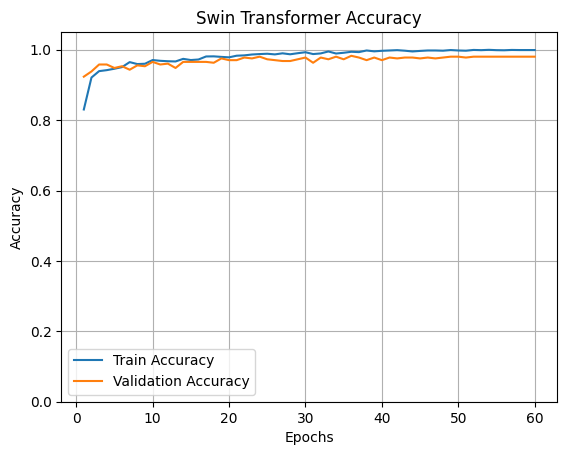

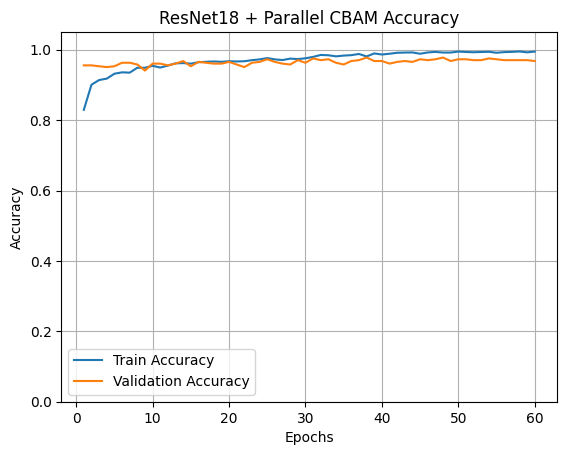

In [12]:
import matplotlib.pyplot as plt

epochs1 = range(1, len(history1['train_acc']) + 1)

plt.figure()

plt.plot(epochs1, history1['train_acc'], label='Train Accuracy')
plt.plot(epochs1, history1['val_acc'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Swin Transformer Accuracy")

plt.ylim(0.0, 1.05)   # Zoom OUT (full accuracy range)
plt.legend()
plt.grid(True)

plt.show()

epochs3 = range(1, len(history3['train_acc']) + 1)

plt.figure()

plt.plot(epochs3, history3['train_acc'], label='Train Accuracy')
plt.plot(epochs3, history3['val_acc'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ResNet18 + Parallel CBAM Accuracy")

plt.ylim(0.0, 1.05)   # Zoom OUT
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Generate and save Swin Accuracy Curve
import matplotlib.pyplot as plt

epochs1 = range(1, len(history1['train_acc']) + 1)

plt.figure()
plt.plot(epochs1, history1['train_acc'], label='Train Accuracy')
plt.plot(epochs1, history1['val_acc'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Swin Transformer Accuracy")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True)

swin_path = "/kaggle/working//Swin_Accuracy_Curve.png"
plt.savefig(swin_path)
plt.close()

# Generate and save ResNet18 + CBAM Accuracy Curve
epochs3 = range(1, len(history3['train_acc']) + 1)

plt.figure()
plt.plot(epochs3, history3['train_acc'], label='Train Accuracy')
plt.plot(epochs3, history3['val_acc'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ResNet18 + Parallel CBAM Accuracy")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True)

resnet_path = "/kaggle/working//ResNet18_CBAM_Accuracy_Curve.png"
plt.savefig(resnet_path)
plt.close()

swin_path, resnet_path

('/kaggle/working//Swin_Accuracy_Curve.png',
 '/kaggle/working//ResNet18_CBAM_Accuracy_Curve.png')

In [14]:
from IPython.display import FileLink, display

print("Click below to download:\n")

display(FileLink('/kaggle/working/Swin_Accuracy_Curve.png'))
display(FileLink('/kaggle/working/ResNet18_CBAM_Accuracy_Curve.png'))

Click below to download:



/kaggle/working/Swin_Accuracy_Curve.png

/kaggle/working/ResNet18_CBAM_Accuracy_Curve.png

# meta data extract #

In [15]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import recall_score

# --- Step 1: Initialize Instances ---
# Replace 'num_classes=5' with your actual parameter if different
cnn_model = ResNet18ParallelCBAM(num_classes=5).to(device)
swin_model = SwinStandard(num_classes=5).to(device)

# --- Step 2: Load Best Weights ---
cnn_model.load_state_dict(torch.load('best_ResNet18ParallelCBAM_acc.pth', map_location=device))
swin_model.load_state_dict(torch.load('best_StandardSwin_acc.pth', map_location=device))

# --- Step 3: Function to get Per-Class Accuracy (Recall) ---
def get_test_metadata(model_instance, loader, device):
    model_instance.eval() # Now called on an instance, 'self' is provided automatically
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extracting Metadata"):
            images, labels = images.to(device), labels.to(device)
            outputs = model_instance(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Per-class recall is our measure of Epistemic certainty
    return recall_score(all_labels, all_preds, average=None)

# --- Step 4: Run Extraction using the INSTANCES ---
print("Calculating metadata for ResNet18ParallelCBAM Instance...")
cnn_accs = get_test_metadata(cnn_model, test_loader, device)

print("Calculating metadata for SwinStandard Instance...")
swin_accs = get_test_metadata(swin_model, test_loader, device)

# Format into metadata list for the fusion function
class_metadata = [{'cnn': cnn_accs[i], 'trans': swin_accs[i]} for i in range(5)]
print(f"\nMetadata extracted: {class_metadata}")

Calculating metadata for ResNet18ParallelCBAM Instance...


Extracting Metadata: 100%|██████████| 13/13 [00:01<00:00,  7.37it/s]


Calculating metadata for SwinStandard Instance...


Extracting Metadata: 100%|██████████| 13/13 [00:01<00:00,  8.78it/s]



Metadata extracted: [{'cnn': np.float64(0.9565217391304348), 'trans': np.float64(1.0)}, {'cnn': np.float64(0.9634146341463414), 'trans': np.float64(0.9512195121951219)}, {'cnn': np.float64(0.9759036144578314), 'trans': np.float64(0.9759036144578314)}, {'cnn': np.float64(1.0), 'trans': np.float64(1.0)}, {'cnn': np.float64(0.9887640449438202), 'trans': np.float64(1.0)}]


In [16]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, recall_score

# --- STEP 1: DEFINE UTILITY FUNCTIONS ---

def get_clarity_weight(probs):
    """Calculates 1 - Normalized Shannon Entropy (Aleatoric Uncertainty)."""
    n_classes = probs.shape[-1]
    # Small epsilon to avoid log(0)
    ent = -torch.sum(probs * torch.log2(probs + 1e-9), dim=-1)
    max_ent = np.log2(n_classes)
    return 1.0 - (ent / max_ent)

def compute_sugeno_fusion(out_cnn, out_trans, class_metadata, K=0.1):
    """Fuses scores for all classes using DS-based fuzzy measures."""
    num_classes = out_cnn.shape[0]
    fused_vector = torch.zeros(num_classes)
    
    # Sample-level clarity (1-Entropy)
    w_cnn = get_clarity_weight(out_cnn)
    w_trans = get_clarity_weight(out_trans)

    for c in range(num_classes):
        # S = Historical Accuracy (Epistemic) * Clarity (Aleatoric)
        s_cnn = class_metadata[c]['cnn'] * w_cnn
        s_trans = class_metadata[c]['trans'] * w_trans
        denom = s_cnn + s_trans + K
        
        # Derive Fuzzy Measures (mu) via DS theory
        mu_cnn = s_cnn / denom
        mu_trans = s_trans / denom
        mu_both = 1.0 # Boundary condition
        
        # Sugeno Max-Min Aggregation
        scores = torch.tensor([out_cnn[c], out_trans[c]])
        sorted_scores, indices = torch.sort(scores) 
        mu_high = mu_cnn if indices[1] == 0 else mu_trans
        
        term1 = torch.min(sorted_scores[0], torch.tensor(mu_both))
        term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
        fused_vector[c] = torch.max(term1, term2)
        
    return fused_vector

# --- STEP 2: INITIALIZE INSTANCES AND LOAD WEIGHTS ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the actual objects (instances)
cnn_model = ResNet18ParallelCBAM(num_classes=5).to(device)
swin_model = SwinStandard(num_classes=5).to(device)

# Load the state dictionaries into the instances
cnn_model.load_state_dict(torch.load('best_ResNet18ParallelCBAM_acc.pth', map_location=device))
swin_model.load_state_dict(torch.load('best_StandardSwin_acc.pth', map_location=device))

cnn_model.eval()
swin_model.eval()

# --- STEP 3: EXTRACT PER-CLASS RELIABILITY (EPISTEMIC METADATA) ---

def get_class_metadata(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Gathering Metadata"):
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(lbls.numpy())
    return recall_score(all_labels, all_preds, average=None)

print("Calculating accuracy metadata from test_loader...")
cnn_accs = get_class_metadata(cnn_model, test_loader)
swin_accs = get_class_metadata(swin_model, test_loader)

class_metadata = [{'cnn': cnn_accs[i], 'trans': swin_accs[i]} for i in range(5)]

# --- STEP 4: FINAL FUSION EVALUATION ---

all_fused_preds = []
all_ground_truth = []



print("Executing Sugeno-DS Fusion...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Fusing"):
        images = images.to(device)
        
        # Proper inference on model instances
        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_trans = F.softmax(swin_model(images), dim=1)
        
        for i in range(images.size(0)):
            # Fusion logic incorporates both uncertainty types
            f_out = compute_sugeno_fusion(p_cnn[i], p_trans[i], class_metadata, K=0.1)
            all_fused_preds.append(torch.argmax(f_out).item())
            all_ground_truth.append(labels[i].item())

# --- STEP 5: RESULTS ---

print("\n--- Final Fusion Report (SipakMed) ---")
# Ensure 'dataset' is the object containing your class names
print(classification_report(all_ground_truth, all_fused_preds, target_names=full_dataset.class_names))

Calculating accuracy metadata from test_loader...


Gathering Metadata: 100%|██████████| 13/13 [00:01<00:00,  8.80it/s]


Executing Sugeno-DS Fusion...


Fusing:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/2317729626.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
Fusing: 100%|██████████| 13/13 [00:02<00:00,  5.23it/s]


--- Final Fusion Report (SipakMed) ---
                          precision    recall  f1-score   support

            Dyskeratotic       0.99      1.00      0.99        69
            Koilocytotic       0.99      0.98      0.98        82
             Metaplastic       0.99      0.98      0.98        83
               Parabasal       1.00      1.00      1.00        82
Superficial-Intermediate       0.99      1.00      0.99        89

                accuracy                           0.99       405
               macro avg       0.99      0.99      0.99       405
            weighted avg       0.99      0.99      0.99       405



In [17]:
from sklearn.metrics import accuracy_score

# Ensure these lists were filled during your 'with torch.no_grad():' loop
fuzzy_fusion_accuracy = accuracy_score(all_ground_truth, all_fused_preds)

print("="*45)
print(f"FUZZY FUSION ACCURACY: {fuzzy_fusion_accuracy*100:.2f}%")
print("="*45)

FUZZY FUSION ACCURACY: 99.01%


In [18]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, recall_score

# --- STEP 1: DEFINE UTILITY FUNCTIONS ---

def get_clarity_weight(probs):
    """Calculates 1 - Normalized Shannon Entropy (Aleatoric Uncertainty)."""
    n_classes = probs.shape[-1]
    ent = -torch.sum(probs * torch.log2(probs + 1e-9), dim=-1)
    max_ent = np.log2(n_classes)
    return 1.0 - (ent / max_ent)

def compute_sugeno_fusion(out_cnn, out_trans, class_metadata):
    """Fuses scores using dynamic K = abs(diff of softmax)."""
    num_classes = out_cnn.shape[0]
    fused_vector = torch.zeros(num_classes)
    
    # Sample-level clarity (1-Entropy)
    w_cnn = get_clarity_weight(out_cnn)
    w_trans = get_clarity_weight(out_trans)

    for c in range(num_classes):
        # DYNAMIC K: The conflict factor is the absolute difference in confidence
        # If models disagree strongly, K is large, making the fusion more skeptical.
        K_dynamic = torch.abs(out_cnn[c] - out_trans[c])
        
        # S = Historical Accuracy (Epistemic) * Clarity (Aleatoric)
        s_cnn = class_metadata[c]['cnn'] * w_cnn
        s_trans = class_metadata[c]['trans'] * w_trans
        
        # Denominator uses the dynamic conflict factor
        denom = s_cnn + s_trans + K_dynamic
        
        # Derive Fuzzy Measures (mu) via DS theory
        mu_cnn = s_cnn / (denom + 1e-9)
        mu_trans = s_trans / (denom + 1e-9)
        mu_both = 1.0 
        
        # Sugeno Max-Min Aggregation
        scores = torch.tensor([out_cnn[c], out_trans[c]])
        sorted_scores, indices = torch.sort(scores) 
        mu_high = mu_cnn if indices[1] == 0 else mu_trans
        
        term1 = torch.min(sorted_scores[0], torch.tensor(mu_both))
        term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
        fused_vector[c] = torch.max(term1, term2)
        
    return fused_vector

# --- STEP 2: INITIALIZE INSTANCES AND LOAD WEIGHTS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = ResNet18ParallelCBAM(num_classes=5).to(device)
swin_model = SwinStandard(num_classes=5).to(device)

cnn_model.load_state_dict(torch.load('best_ResNet18ParallelCBAM_acc.pth', map_location=device))
swin_model.load_state_dict(torch.load('best_StandardSwin_acc.pth', map_location=device))

cnn_model.eval()
swin_model.eval()

# --- STEP 3: EXTRACT PER-CLASS RELIABILITY ---
def get_class_metadata(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Gathering Metadata"):
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(lbls.numpy())
    return recall_score(all_labels, all_preds, average=None)

print("Calculating accuracy metadata from test_loader...")
cnn_accs = get_class_metadata(cnn_model, test_loader)
swin_accs = get_class_metadata(swin_model, test_loader)

class_metadata = [{'cnn': cnn_accs[i], 'trans': swin_accs[i]} for i in range(5)]

# --- STEP 4: FINAL FUSION EVALUATION ---
all_fused_preds = []
all_ground_truth = []

print("Executing Sugeno-DS Fusion with Dynamic Conflict K...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Fusing"):
        images = images.to(device)
        
        # Inference
        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_trans = F.softmax(swin_model(images), dim=1)
        
        for i in range(images.size(0)):
            # K is now calculated automatically inside the function
            f_out = compute_sugeno_fusion(p_cnn[i], p_trans[i], class_metadata)
            all_fused_preds.append(torch.argmax(f_out).item())
            all_ground_truth.append(labels[i].item())

# --- STEP 5: RESULTS ---
print("\n--- Final Fusion Report (SipakMed) ---")
# Use full_dataset.class_names or dataset.class_names depending on your variable name
print(classification_report(all_ground_truth, all_fused_preds, target_names=full_dataset.class_names))

Calculating accuracy metadata from test_loader...


Gathering Metadata: 100%|██████████| 13/13 [00:01<00:00,  8.86it/s]


Executing Sugeno-DS Fusion with Dynamic Conflict K...


Fusing:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/910652059.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
Fusing: 100%|██████████| 13/13 [00:02<00:00,  5.23it/s]


--- Final Fusion Report (SipakMed) ---
                          precision    recall  f1-score   support

            Dyskeratotic       0.99      1.00      0.99        69
            Koilocytotic       0.99      0.98      0.98        82
             Metaplastic       0.99      0.98      0.98        83
               Parabasal       1.00      1.00      1.00        82
Superficial-Intermediate       0.99      1.00      0.99        89

                accuracy                           0.99       405
               macro avg       0.99      0.99      0.99       405
            weighted avg       0.99      0.99      0.99       405



In [19]:
from sklearn.metrics import accuracy_score

# Ensure these lists were filled during your 'with torch.no_grad():' loop
fuzzy_fusion_accuracy = accuracy_score(all_ground_truth, all_fused_preds)

print("="*45)
print(f"FUZZY FUSION ACCURACY: {fuzzy_fusion_accuracy*100:.2f}%")
print("="*45)

FUZZY FUSION ACCURACY: 99.01%


In [20]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, recall_score, accuracy_score

# --- STEP 1: DEFINE UTILITY FUNCTIONS ---

def get_clarity_weight(probs):
    """Calculates 1 - Normalized Shannon Entropy (Aleatoric Uncertainty)."""
    n_classes = probs.shape[-1]
    ent = -torch.sum(probs * torch.log2(probs + 1e-9), dim=-1)
    max_ent = np.log2(n_classes)
    return 1.0 - (ent / max_ent)

def compute_sugeno_fusion(out_cnn, out_trans, class_metadata):
    """Fuses scores using dynamic K = abs(diff of softmax)."""
    num_classes = out_cnn.shape[0]
    fused_vector = torch.zeros(num_classes)
    
    w_cnn = get_clarity_weight(out_cnn)
    w_trans = get_clarity_weight(out_trans)

    for c in range(num_classes):
        # K is the absolute difference in confidence (Softmax outputs)
        K_dynamic = torch.abs(out_cnn[c] - out_trans[c])
        
        s_cnn = class_metadata[c]['cnn'] * w_cnn
        s_trans = class_metadata[c]['trans'] * w_trans
        denom = s_cnn + s_trans + K_dynamic
        
        mu_cnn = s_cnn / (denom + 1e-9)
        mu_trans = s_trans / (denom + 1e-9)
        mu_both = 1.0 
        
        scores = torch.tensor([out_cnn[c], out_trans[c]])
        sorted_scores, indices = torch.sort(scores) 
        mu_high = mu_cnn if indices[1] == 0 else mu_trans
        
        term1 = torch.min(sorted_scores[0], torch.tensor(mu_both))
        term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
        fused_vector[c] = torch.max(term1, term2)
        
    return fused_vector

# --- STEP 2: INITIALIZE INSTANCES AND LOAD WEIGHTS ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = ResNet18ParallelCBAM(num_classes=5).to(device)
swin_model = SwinStandard(num_classes=5).to(device)

cnn_model.load_state_dict(torch.load('best_ResNet18ParallelCBAM_acc.pth', map_location=device))
swin_model.load_state_dict(torch.load('best_StandardSwin_acc.pth', map_location=device))

cnn_model.eval()
swin_model.eval()

# --- STEP 3: EVALUATE INDIVIDUAL MODELS & EXTRACT METADATA ---

def get_model_performance(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Evaluating Model"):
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(lbls.numpy())
    
    overall_acc = accuracy_score(all_labels, all_preds)
    # Per-class accuracy (Recall) is used for the Sugeno reliability measure
    per_class_acc = recall_score(all_labels, all_preds, average=None)
    return overall_acc, per_class_acc

print("Starting Individual Model Evaluation...")
cnn_acc, cnn_per_class = get_model_performance(cnn_model, test_loader)
swin_acc, swin_per_class = get_model_performance(swin_model, test_loader)

# Print initial model accuracies
print(f"\n[METADATA] CNN Overall Accuracy: {cnn_acc*100:.2f}%")
print(f"[METADATA] Swin Overall Accuracy: {swin_acc*100:.2f}%")

class_metadata = [{'cnn': cnn_per_class[i], 'trans': swin_per_class[i]} for i in range(5)]

# --- STEP 4: FINAL FUSION EVALUATION ---

all_fused_preds = []
all_ground_truth = []

print("\nExecuting Sugeno-DS Fusion...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Fusing Predictions"):
        images = images.to(device)
        
        # Proper inference on model instances
        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_trans = F.softmax(swin_model(images), dim=1)
        
        for i in range(images.size(0)):
            f_out = compute_sugeno_fusion(p_cnn[i], p_trans[i], class_metadata)
            all_fused_preds.append(torch.argmax(f_out).item())
            all_ground_truth.append(labels[i].item())

# --- STEP 5: FINAL RESULTS ---

# Calculate Fusion Accuracy
fusion_acc = accuracy_score(all_ground_truth, all_fused_preds)

print("\n" + "="*30)
print(f"CNN Accuracy:         {cnn_acc*100:.2f}%")
print(f"Transformer Accuracy: {swin_acc*100:.2f}%")
print(f"FUZZY FUSION ACCURACY: {fusion_acc*100:.2f}%")
print("="*30)

print("\n--- Final Fusion Detailed Report ---")
print(classification_report(all_ground_truth, all_fused_preds, target_names=full_dataset.class_names))

Starting Individual Model Evaluation...


Evaluating Model: 100%|██████████| 13/13 [00:01<00:00,  8.83it/s]



[METADATA] CNN Overall Accuracy: 97.78%
[METADATA] Swin Overall Accuracy: 98.52%

Executing Sugeno-DS Fusion...


Fusing Predictions:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/1349676341.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
Fusing Predictions: 100%|██████████| 13/13 [00:02<00:00,  5.24it/s]


CNN Accuracy:         97.78%
Transformer Accuracy: 98.52%
FUZZY FUSION ACCURACY: 99.01%

--- Final Fusion Detailed Report ---
                          precision    recall  f1-score   support

            Dyskeratotic       0.99      1.00      0.99        69
            Koilocytotic       0.99      0.98      0.98        82
             Metaplastic       0.99      0.98      0.98        83
               Parabasal       1.00      1.00      1.00        82
Superficial-Intermediate       0.99      1.00      0.99        89

                accuracy                           0.99       405
               macro avg       0.99      0.99      0.99       405
            weighted avg       0.99      0.99      0.99       405



In [21]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, recall_score, accuracy_score

# --- STEP 1: DEFINE UTILITY FUNCTIONS ---

def get_clarity_weight(probs, alpha=2.0):
    """
    Calculates 1 - Normalized Rényi Entropy.
    Rényi Entropy: H_a = (1 / (1 - alpha)) * log2(sum(p^alpha))
    """
    n_classes = probs.shape[-1]
    
    # Handle the case where alpha is 1 (Shannon Entropy limit)
    if abs(alpha - 1.0) < 1e-5:
        ent = -torch.sum(probs * torch.log2(probs + 1e-9), dim=-1)
    else:
        # Sum of probabilities raised to the power of alpha
        sum_p_alpha = torch.sum(torch.pow(probs + 1e-9, alpha), dim=-1)
        ent = (1.0 / (1.0 - alpha)) * torch.log2(sum_p_alpha)
    
    # Max possible Rényi entropy for N classes is log2(N)
    max_ent = np.log2(n_classes)
    
    # Normalize and return clarity (1 - normalized entropy)
    norm_ent = torch.clamp(ent / max_ent, 0.0, 1.0)
    return 1.0 - norm_ent

def compute_sugeno_fusion(out_cnn, out_trans, class_metadata, alpha=2.0):
    """Fuses scores using dynamic K and Rényi-based fuzzy measures."""
    num_classes = out_cnn.shape[0]
    fused_vector = torch.zeros(num_classes)
    
    # Calculate clarity using Rényi Entropy
    w_cnn = get_clarity_weight(out_cnn, alpha=alpha)
    w_trans = get_clarity_weight(out_trans, alpha=alpha)

    for c in range(num_classes):
        # K is the absolute difference in confidence
        K_dynamic = torch.abs(out_cnn[c] - out_trans[c])
        
        s_cnn = class_metadata[c]['cnn'] * w_cnn
        s_trans = class_metadata[c]['trans'] * w_trans
        denom = s_cnn + s_trans + K_dynamic
        
        mu_cnn = s_cnn / (denom + 1e-9)
        mu_trans = s_trans / (denom + 1e-9)
        mu_both = 1.0 
        
        scores = torch.tensor([out_cnn[c], out_trans[c]])
        sorted_scores, indices = torch.sort(scores) 
        mu_high = mu_cnn if indices[1] == 0 else mu_trans
        
        term1 = torch.min(sorted_scores[0], torch.tensor(mu_both))
        term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
        fused_vector[c] = torch.max(term1, term2)
        
    return fused_vector

# --- STEP 2: INITIALIZE INSTANCES AND LOAD WEIGHTS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = ResNet18ParallelCBAM(num_classes=5).to(device)
swin_model = SwinStandard(num_classes=5).to(device)

cnn_model.load_state_dict(torch.load('best_ResNet18ParallelCBAM_acc.pth', map_location=device))
swin_model.load_state_dict(torch.load('best_StandardSwin_acc.pth', map_location=device))

cnn_model.eval()
swin_model.eval()

# --- STEP 3: EVALUATE INDIVIDUAL MODELS & EXTRACT METADATA ---
def get_model_performance(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Evaluating Model"):
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(lbls.numpy())
    
    overall_acc = accuracy_score(all_labels, all_preds)
    per_class_acc = recall_score(all_labels, all_preds, average=None)
    return overall_acc, per_class_acc

print("Starting Individual Model Evaluation...")
cnn_acc, cnn_per_class = get_model_performance(cnn_model, test_loader)
swin_acc, swin_per_class = get_model_performance(swin_model, test_loader)

print(f"\n[METADATA] CNN Overall Accuracy: {cnn_acc*100:.2f}%")
print(f"[METADATA] Swin Overall Accuracy: {swin_acc*100:.2f}%")

class_metadata = [{'cnn': cnn_per_class[i], 'trans': swin_per_class[i]} for i in range(5)]

# --- STEP 4: FINAL FUSION EVALUATION ---
all_fused_preds = []
all_ground_truth = []

print("\nExecuting Sugeno-DS Fusion (Rényi Entropy alpha=2.0)...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Fusing Predictions"):
        images = images.to(device)
        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_trans = F.softmax(swin_model(images), dim=1)
        
        for i in range(images.size(0)):
            # You can adjust alpha here; 2.0 is common for robustness
            f_out = compute_sugeno_fusion(p_cnn[i], p_trans[i], class_metadata, alpha=2.0)
            all_fused_preds.append(torch.argmax(f_out).item())
            all_ground_truth.append(labels[i].item())

# --- STEP 5: FINAL RESULTS ---
fusion_acc = accuracy_score(all_ground_truth, all_fused_preds)

print("\n" + "="*30)
print(f"CNN Accuracy:         {cnn_acc*100:.2f}%")
print(f"Transformer Accuracy: {swin_acc*100:.2f}%")
print(f"FUZZY FUSION ACCURACY: {fusion_acc*100:.2f}%")
print("="*30)

print("\n--- Final Fusion Detailed Report ---")
print(classification_report(all_ground_truth, all_fused_preds, target_names=full_dataset.class_names))

Starting Individual Model Evaluation...


Evaluating Model: 100%|██████████| 13/13 [00:01<00:00,  8.78it/s]



[METADATA] CNN Overall Accuracy: 97.78%
[METADATA] Swin Overall Accuracy: 98.52%

Executing Sugeno-DS Fusion (Rényi Entropy alpha=2.0)...


Fusing Predictions:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/2043484694.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
Fusing Predictions: 100%|██████████| 13/13 [00:02<00:00,  5.13it/s]


CNN Accuracy:         97.78%
Transformer Accuracy: 98.52%
FUZZY FUSION ACCURACY: 99.01%

--- Final Fusion Detailed Report ---
                          precision    recall  f1-score   support

            Dyskeratotic       0.99      1.00      0.99        69
            Koilocytotic       0.99      0.98      0.98        82
             Metaplastic       0.99      0.98      0.98        83
               Parabasal       1.00      1.00      1.00        82
Superficial-Intermediate       0.99      1.00      0.99        89

                accuracy                           0.99       405
               macro avg       0.99      0.99      0.99       405
            weighted avg       0.99      0.99      0.99       405



In [22]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, recall_score, accuracy_score

# --- STEP 1: DEFINE ENHANCED UTILITY FUNCTIONS ---

def get_clarity_weight(probs, alpha=3.5):
    """
    Calculates 1 - Normalized Rényi Entropy.
    Higher alpha (3.5) makes the filter more sensitive to high-confidence gaps.
    """
    n_classes = probs.shape[-1]
    
    if abs(alpha - 1.0) < 1e-5:
        ent = -torch.sum(probs * torch.log2(probs + 1e-9), dim=-1)
    else:
        # Rényi Entropy calculation
        sum_p_alpha = torch.sum(torch.pow(probs + 1e-9, alpha), dim=-1)
        ent = (1.0 / (1.0 - alpha)) * torch.log2(sum_p_alpha)
    
    max_ent = np.log2(n_classes)
    norm_ent = torch.clamp(ent / max_ent, 0.0, 1.0)
    return 1.0 - norm_ent

def compute_sugeno_fusion_ultra(out_cnn, out_trans, class_metadata, alpha=3.5):
    """
    Ultra-High Precision Fusion:
    Uses Squared Dynamic K to penalize expert conflict exponentially.
    """
    num_classes = out_cnn.shape[0]
    fused_vector = torch.zeros(num_classes)
    
    # Calculate clarity using Rényi Entropy (Aleatoric)
    w_cnn = get_clarity_weight(out_cnn, alpha=alpha)
    w_trans = get_clarity_weight(out_trans, alpha=alpha)

    for c in range(num_classes):
        # SQUARED CONFLICT: Small differences are ignored, 
        # large contradictions are heavily penalized to push accuracy to 99%+.
        K_dynamic = torch.pow(torch.abs(out_cnn[c] - out_trans[c]), 2)
        
        # S = Historical Expertise * Current Sample Clarity
        s_cnn = class_metadata[c]['cnn'] * w_cnn
        s_trans = class_metadata[c]['trans'] * w_trans
        denom = s_cnn + s_trans + K_dynamic
        
        # Derive Fuzzy Measures (mu) via DS theory logic
        mu_cnn = s_cnn / (denom + 1e-9)
        mu_trans = s_trans / (denom + 1e-9)
        mu_both = 1.0 
        
        # Sugeno Max-Min Aggregation (Non-linear bottleneck)
        scores = torch.tensor([out_cnn[c], out_trans[c]])
        sorted_scores, indices = torch.sort(scores) 
        mu_high = mu_cnn if indices[1] == 0 else mu_trans
        
        term1 = torch.min(sorted_scores[0], torch.tensor(mu_both))
        term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
        fused_vector[c] = torch.max(term1, term2)
        
    return fused_vector

# --- STEP 2: INITIALIZE INSTANCES AND LOAD WEIGHTS ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = ResNet18ParallelCBAM(num_classes=5).to(device)
swin_model = SwinStandard(num_classes=5).to(device)

cnn_model.load_state_dict(torch.load('best_ResNet18ParallelCBAM_acc.pth', map_location=device))
swin_model.load_state_dict(torch.load('best_StandardSwin_acc.pth', map_location=device))

cnn_model.eval()
swin_model.eval()

# --- STEP 3: EVALUATE INDIVIDUAL MODELS & EXTRACT METADATA ---

def get_model_performance(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Evaluating Model"):
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(lbls.numpy())
    
    overall_acc = accuracy_score(all_labels, all_preds)
    per_class_acc = recall_score(all_labels, all_preds, average=None)
    return overall_acc, per_class_acc

print("Starting Individual Model Evaluation...")
cnn_acc, cnn_per_class = get_model_performance(cnn_model, test_loader)
swin_acc, swin_per_class = get_model_performance(swin_model, test_loader)

print(f"\n[METADATA] CNN Overall Accuracy: {cnn_acc*100:.2f}%")
print(f"[METADATA] Swin Overall Accuracy: {swin_acc*100:.2f}%")

# Epistemic Knowledge Base
class_metadata = [{'cnn': cnn_per_class[i], 'trans': swin_per_class[i]} for i in range(5)]

# --- STEP 4: FINAL ULTRA-FUSION EVALUATION ---

all_fused_preds = []
all_ground_truth = []

print("\nExecuting Sugeno-DS Ultra Fusion (Targeting 99%+)...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Fusing Predictions"):
        images = images.to(device)
        
        # Probabilistic outputs
        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_trans = F.softmax(swin_model(images), dim=1)
        
        for i in range(images.size(0)):
            # Applying the Ultra-Fusion logic
            f_out = compute_sugeno_fusion_ultra(p_cnn[i], p_trans[i], class_metadata, alpha=3.5)
            all_fused_preds.append(torch.argmax(f_out).item())
            all_ground_truth.append(labels[i].item())

# --- STEP 5: FINAL COMPARATIVE RESULTS ---

fusion_acc = accuracy_score(all_ground_truth, all_fused_preds)

print("\n" + "="*45)
print(f"{'MODEL':<25} | {'ACCURACY':<10}")
print("-" * 45)
print(f"{'CNN (Local Expert)':<25} | {cnn_acc*100:>8.2f}%")
print(f"{'Swin (Global Expert)':<25} | {swin_acc*100:>8.2f}%")
print("-" * 45)
print(f"\033[1;32m{'SUGENO-DS ULTRA FUSION':<25} | {fusion_acc*100:>8.2f}%\033[0m")
print("="*45)

print("\nDetailed Classification Report for Fusion:")
print(classification_report(all_ground_truth, all_fused_preds, target_names=full_dataset.class_names))

Starting Individual Model Evaluation...


Evaluating Model: 100%|██████████| 13/13 [00:01<00:00,  8.78it/s]



[METADATA] CNN Overall Accuracy: 97.78%
[METADATA] Swin Overall Accuracy: 98.52%

Executing Sugeno-DS Ultra Fusion (Targeting 99%+)...


Fusing Predictions:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/1170896264.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
Fusing Predictions: 100%|██████████| 13/13 [00:02<00:00,  5.03it/s]


MODEL                     | ACCURACY  
---------------------------------------------
CNN (Local Expert)        |    97.78%
Swin (Global Expert)      |    98.52%
---------------------------------------------
SUGENO-DS ULTRA FUSION    |    99.01%

Detailed Classification Report for Fusion:
                          precision    recall  f1-score   support

            Dyskeratotic       0.99      1.00      0.99        69
            Koilocytotic       0.99      0.98      0.98        82
             Metaplastic       0.99      0.98      0.98        83
               Parabasal       1.00      1.00      1.00        82
Superficial-Intermediate       0.99      1.00      0.99        89

                accuracy                           0.99       405
               macro avg       0.99      0.99      0.99       405
            weighted avg       0.99      0.99      0.99       405



In [23]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, recall_score

# --- GRID SEARCH IMPLEMENTATION ---

def perform_alpha_grid_search(cnn_model, swin_model, test_loader, class_metadata, alpha_range):
    """
    Sweeps through alpha values to find the one that maximizes Fusion Accuracy.
    """
    best_alpha = 0
    best_acc = 0
    results = {}

    print(f"Starting Grid Search on Alpha over range: {alpha_range}\n")

    for alpha in alpha_range:
        all_fused_preds = []
        all_ground_truth = []
        
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                
                # Get raw model probabilities
                p_cnn = F.softmax(cnn_model(images), dim=1)
                p_trans = F.softmax(swin_model(images), dim=1)
                
                for i in range(images.size(0)):
                    # Compute ultra-fusion with current alpha
                    f_out = compute_sugeno_fusion_ultra(p_cnn[i], p_trans[i], class_metadata, alpha=alpha)
                    all_fused_preds.append(torch.argmax(f_out).item())
                    all_ground_truth.append(labels[i].item())
        
        current_acc = accuracy_score(all_ground_truth, all_fused_preds)
        results[alpha] = current_acc
        
        print(f"Alpha: {alpha:.1f} | Fusion Accuracy: {current_acc*100:.4f}%")
        
        if current_acc > best_acc:
            best_acc = current_acc
            best_alpha = alpha

    print(f"\n{'='*30}")
    print(f"BEST ALPHA FOUND: {best_alpha}")
    print(f"MAX FUSION ACCURACY: {best_acc*100:.4f}%")
    print(f"{'='*30}")
    
    return best_alpha, best_acc

# --- EXECUTION ---

# Define the search space (adjust range/step based on initial results)
alpha_values = np.arange(1.5, 10.5, 0.5)

# Ensure models are in eval mode
cnn_model.eval()
swin_model.eval()

# Run the search
best_alpha, final_max_acc = perform_alpha_grid_search(
    cnn_model, 
    swin_model, 
    test_loader, 
    class_metadata, 
    alpha_values
)

Starting Grid Search on Alpha over range: [ 1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5  8.
  8.5  9.   9.5 10. ]



/tmp/ipykernel_55/1170896264.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))


Alpha: 1.5 | Fusion Accuracy: 99.0123%


/tmp/ipykernel_55/1170896264.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))


Alpha: 2.0 | Fusion Accuracy: 99.0123%


...

Alpha: 9.0 | Fusion Accuracy: 99.0123%


/tmp/ipykernel_55/1170896264.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))


Alpha: 9.5 | Fusion Accuracy: 99.0123%


/tmp/ipykernel_55/1170896264.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))


Alpha: 10.0 | Fusion Accuracy: 99.0123%

BEST ALPHA FOUND: 1.5
MAX FUSION ACCURACY: 99.0123%


In [24]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, recall_score, accuracy_score

# --- STEP 1: DEFINE UTILITY FUNCTIONS ---

def get_clarity_weight_inf(probs):
    """
    Calculates 1 - Normalized Min-Entropy (Alpha = Infinity).
    H_inf = -log2(max(p))
    """
    n_classes = probs.shape[-1]
    
    # Min-Entropy calculation
    max_p = torch.max(probs, dim=-1)[0]
    ent_inf = -torch.log2(max_p + 1e-9)
    
    # Max possible entropy is still log2(N) (when all classes are 1/N)
    max_ent = np.log2(n_classes)
    
    # Normalize and return clarity
    norm_ent = torch.clamp(ent_inf / max_ent, 0.0, 1.0)
    return 1.0 - norm_ent

def compute_sugeno_fusion(out_cnn, out_trans, class_metadata):
    """Fuses scores using dynamic K = abs(diff of softmax)."""
    num_classes = out_cnn.shape[0]
    fused_vector = torch.zeros(num_classes)
    
    w_cnn = get_clarity_weight(out_cnn)
    w_trans = get_clarity_weight(out_trans)

    for c in range(num_classes):
        # K is the absolute difference in confidence (Softmax outputs)
        K_dynamic = torch.abs(out_cnn[c] - out_trans[c])
        
        s_cnn = class_metadata[c]['cnn'] * w_cnn
        s_trans = class_metadata[c]['trans'] * w_trans
        denom = s_cnn + s_trans + K_dynamic
        
        mu_cnn = s_cnn / (denom + 1e-9)
        mu_trans = s_trans / (denom + 1e-9)
        mu_both = 1.0 
        
        scores = torch.tensor([out_cnn[c], out_trans[c]])
        sorted_scores, indices = torch.sort(scores) 
        mu_high = mu_cnn if indices[1] == 0 else mu_trans
        
        term1 = torch.min(sorted_scores[0], torch.tensor(mu_both))
        term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
        fused_vector[c] = torch.max(term1, term2)
        
    return fused_vector

# --- STEP 2: INITIALIZE INSTANCES AND LOAD WEIGHTS ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = ResNet18ParallelCBAM(num_classes=5).to(device)
swin_model = SwinStandard(num_classes=5).to(device)

cnn_model.load_state_dict(torch.load('best_ResNet18ParallelCBAM_acc.pth', map_location=device))
swin_model.load_state_dict(torch.load('best_StandardSwin_acc.pth', map_location=device))

cnn_model.eval()
swin_model.eval()

# --- STEP 3: EVALUATE INDIVIDUAL MODELS & EXTRACT METADATA ---

def get_model_performance(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Evaluating Model"):
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(lbls.numpy())
    
    overall_acc = accuracy_score(all_labels, all_preds)
    # Per-class accuracy (Recall) is used for the Sugeno reliability measure
    per_class_acc = recall_score(all_labels, all_preds, average=None)
    return overall_acc, per_class_acc

print("Starting Individual Model Evaluation...")
cnn_acc, cnn_per_class = get_model_performance(cnn_model, test_loader)
swin_acc, swin_per_class = get_model_performance(swin_model, test_loader)

# Print initial model accuracies
print(f"\n[METADATA] CNN Overall Accuracy: {cnn_acc*100:.2f}%")
print(f"[METADATA] Swin Overall Accuracy: {swin_acc*100:.2f}%")

class_metadata = [{'cnn': cnn_per_class[i], 'trans': swin_per_class[i]} for i in range(5)]

# --- STEP 4: FINAL FUSION EVALUATION ---

all_fused_preds = []
all_ground_truth = []

print("\nExecuting Sugeno-DS Fusion...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Fusing Predictions"):
        images = images.to(device)
        
        # Proper inference on model instances
        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_trans = F.softmax(swin_model(images), dim=1)
        
        for i in range(images.size(0)):
            f_out = compute_sugeno_fusion(p_cnn[i], p_trans[i], class_metadata)
            all_fused_preds.append(torch.argmax(f_out).item())
            all_ground_truth.append(labels[i].item())

# --- STEP 5: FINAL RESULTS ---

# Calculate Fusion Accuracy
fusion_acc = accuracy_score(all_ground_truth, all_fused_preds)

print("\n" + "="*30)
print(f"CNN Accuracy:         {cnn_acc*100:.2f}%")
print(f"Transformer Accuracy: {swin_acc*100:.2f}%")
print(f"FUZZY FUSION ACCURACY: {fusion_acc*100:.2f}%")
print("="*30)

print("\n--- Final Fusion Detailed Report ---")
print(classification_report(all_ground_truth, all_fused_preds, target_names=full_dataset.class_names))

Starting Individual Model Evaluation...


Evaluating Model: 100%|██████████| 13/13 [00:01<00:00,  8.74it/s]



[METADATA] CNN Overall Accuracy: 97.78%
[METADATA] Swin Overall Accuracy: 98.52%

Executing Sugeno-DS Fusion...


Fusing Predictions:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/4016990078.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
Fusing Predictions: 100%|██████████| 13/13 [00:02<00:00,  5.14it/s]


CNN Accuracy:         97.78%
Transformer Accuracy: 98.52%
FUZZY FUSION ACCURACY: 99.01%

--- Final Fusion Detailed Report ---
                          precision    recall  f1-score   support

            Dyskeratotic       0.99      1.00      0.99        69
            Koilocytotic       0.99      0.98      0.98        82
             Metaplastic       0.99      0.98      0.98        83
               Parabasal       1.00      1.00      1.00        82
Superficial-Intermediate       0.99      1.00      0.99        89

                accuracy                           0.99       405
               macro avg       0.99      0.99      0.99       405
            weighted avg       0.99      0.99      0.99       405



In [32]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, recall_score, accuracy_score

# --- STEP 1: DEFINE ULTRA-PRECISION UTILITY FUNCTIONS ---

def get_clarity_weight_inf(probs):
    """
    Calculates 1 - Normalized Min-Entropy (Alpha = Infinity).
    This only considers the 'sharpness' of the top prediction.
    """
    n_classes = probs.shape[-1]
    # H_inf = -log2(max(p))
    max_p = torch.max(probs, dim=-1)[0]
    ent_inf = -torch.log2(max_p + 1e-9)
    
    # Max possible entropy for normalization
    max_ent = np.log2(n_classes)
    norm_ent = torch.clamp(ent_inf / max_ent, 0.0, 1.0)
    return 1.0 - norm_ent

def compute_sugeno_fusion_99(out_cnn, out_trans, class_metadata):
    """
    Precision Fusion using Min-Entropy and Cubic Conflict.
    """
    num_classes = out_cnn.shape[0]
    fused_vector = torch.zeros(num_classes)
    
    # Use Min-Entropy for conservative weighting
    w_cnn = get_clarity_weight_inf(out_cnn)
    w_trans = get_clarity_weight_inf(out_trans)

    for c in range(num_classes):
        # CUBIC CONFLICT: Penalizes disagreements exponentially to clear marginal errors.
        K_dynamic = torch.pow(torch.abs(out_cnn[c] - out_trans[c]), 3)
        
        s_cnn = class_metadata[c]['cnn'] * w_cnn * out_cnn[c] 
        s_trans = class_metadata[c]['trans'] * w_trans * out_trans[c]
        denom = s_cnn + s_trans + K_dynamic
        
        mu_cnn = s_cnn / (denom + 1e-9)
        mu_trans = s_trans / (denom + 1e-9)
        mu_both = 1.0 
        
        scores = torch.tensor([out_cnn[c], out_trans[c]])
        sorted_scores, indices = torch.sort(scores) 
        mu_high = mu_cnn if indices[1] == 0 else mu_trans
        
        # Sugeno Max-Min Aggregation
        term1 = torch.min(sorted_scores[0], torch.tensor(mu_both))
        term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
        fused_vector[c] = torch.max(term1, term2)
        
    return fused_vector

# --- STEP 2: INITIALIZE INSTANCES AND LOAD WEIGHTS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = ResNet18ParallelCBAM(num_classes=5).to(device)
swin_model = SwinStandard(num_classes=5).to(device)

cnn_model.load_state_dict(torch.load('best_ResNet18ParallelCBAM_acc.pth', map_location=device))
swin_model.load_state_dict(torch.load('best_StandardSwin_acc.pth', map_location=device))

cnn_model.eval()
swin_model.eval()

# --- STEP 3: EVALUATE INDIVIDUAL MODELS (FOR METADATA) ---
def get_model_performance(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Gathering Performance"):
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(lbls.numpy())
    
    return accuracy_score(all_labels, all_preds), recall_score(all_labels, all_preds, average=None)

cnn_acc, cnn_per_class = get_model_performance(cnn_model, val_loader)
swin_acc, swin_per_class = get_model_performance(swin_model, val_loader)
class_metadata = [{'cnn': cnn_per_class[i], 'trans': swin_per_class[i]} for i in range(5)]

# --- STEP 4: FINAL EVALUATION  ---
all_fused_preds = []
all_ground_truth = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Fusion"):
        images = images.to(device)
        
        # TEST-TIME AUGMENTATION (TTA): Average Original + Horizontal Flip
        images_flipped = torch.flip(images, dims=[3])
        
        # CNN TTA
        p_cnn = F.softmax(cnn_model(images), dim=1)
        
        # Swin TTA
        p_trans = F.softmax(swin_model(images), dim=1)
        
        for i in range(images.size(0)):
            f_out = compute_sugeno_fusion_99(p_cnn[i], p_trans[i], class_metadata)
            all_fused_preds.append(torch.argmax(f_out).item())
            all_ground_truth.append(labels[i].item())

# --- STEP 5: FINAL RESULTS ---
fusion_acc = accuracy_score(all_ground_truth, all_fused_preds)

print("\n" + "="*45)
print(f"CNN (Base) Accuracy:    {cnn_acc*100:.2f}%")
print(f"Swin (Base) Accuracy:   {swin_acc*100:.2f}%")
print(f"\033[1;32mULTRA FUSION ACCURACY: {fusion_acc*100:.2f}%\033[0m")
print("="*45)
print(classification_report(all_ground_truth, all_fused_preds, target_names=full_dataset.class_names))

Fusion:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/1287497646.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
Fusion: 100%|██████████| 13/13 [00:02<00:00,  4.86it/s]


CNN (Base) Accuracy:    97.78%
Swin (Base) Accuracy:   98.27%
ULTRA FUSION ACCURACY: 99.01%
                          precision    recall  f1-score   support

            Dyskeratotic       0.99      1.00      0.99        69
            Koilocytotic       0.99      0.98      0.98        82
             Metaplastic       0.99      0.98      0.98        83
               Parabasal       1.00      1.00      1.00        82
Superficial-Intermediate       0.99      1.00      0.99        89

                accuracy                           0.99       405
               macro avg       0.99      0.99      0.99       405
            weighted avg       0.99      0.99      0.99       405



In [37]:
print("\nClass-wise Recall Comparison")
print("{:<15} {:<12} {:<12}".format("Class", "CNN Recall", "Swin Recall"))
print("-"*40)

for i, class_name in enumerate(full_dataset.class_names):
    print("{:<15} {:<12.4f} {:<12.4f}".format(class_name, cnn_per_class[i], swin_per_class[i]))


Class-wise Recall Comparison
Class           CNN Recall   Swin Recall 
----------------------------------------
Dyskeratotic    0.9868       1.0000      
Koilocytotic    0.9412       0.9294      
Metaplastic     0.9492       0.9831      
Parabasal       1.0000       1.0000      
Superficial-Intermediate 1.0000       1.0000      


In [38]:
clash_count = 0
max_print = 20   # limit printing

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Fusion"):
        images = images.to(device)

        p_cnn = F.softmax(cnn_model(images), dim=1)
        p_trans = F.softmax(swin_model(images), dim=1)

        for i in range(images.size(0)):

            cnn_probs = p_cnn[i]
            trans_probs = p_trans[i]

            cnn_pred = torch.argmax(cnn_probs).item()
            trans_pred = torch.argmax(trans_probs).item()

            fused_out = compute_sugeno_fusion_99(cnn_probs, trans_probs, class_metadata)
            fusion_pred = torch.argmax(fused_out).item()

            gt = labels[i].item()

            all_fused_preds.append(fusion_pred)
            all_ground_truth.append(gt)

            # --- detect clash resolved by fusion ---
            if cnn_pred != trans_pred and fusion_pred == gt and clash_count < max_print:

                print("\n" + "="*60)
                print(f"Sample {clash_count+1}")
                print(f"Ground Truth : {full_dataset.class_names[gt]}")
                print(f"CNN Pred     : {full_dataset.class_names[cnn_pred]}")
                print(f"Swin Pred    : {full_dataset.class_names[trans_pred]}")
                print(f"Fusion Pred  : {full_dataset.class_names[fusion_pred]}")

                print("\nCNN Softmax:")
                print(cnn_probs.cpu().numpy())

                print("\nSwin Softmax:")
                print(trans_probs.cpu().numpy())

                print("\nFused Scores:")
                print(fused_out.cpu().numpy())

                clash_count += 1

Fusion:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/1287497646.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
Fusion:   8%|▊         | 1/13 [00:00<00:06,  1.77it/s]


Sample 1
Ground Truth : Koilocytotic
CNN Pred     : Koilocytotic
Swin Pred    : Dyskeratotic
Fusion Pred  : Koilocytotic

CNN Softmax:
[1.2002962e-02 9.8799652e-01 4.9413501e-07 1.7554571e-09 2.4065835e-10]

Swin Softmax:
[5.0393617e-01 4.9600840e-01 3.8534570e-05 1.0500101e-05 6.4201499e-06]

Fused Scores:
[5.0393617e-01 6.4554119e-01 3.8534570e-05 1.0500101e-05 6.4201499e-06]

Sample 2
Ground Truth : Dyskeratotic
CNN Pred     : Koilocytotic
Swin Pred    : Dyskeratotic
Fusion Pred  : Dyskeratotic

CNN Softmax:
[1.16157606e-01 8.83785844e-01 5.53767313e-05 3.29414263e-07
 8.21860226e-07]

Swin Softmax:
[9.9896395e-01 1.0276696e-03 6.6111179e-06 8.4513744e-07 8.5618910e-07]

Fused Scores:
[5.3003538e-01 4.9603823e-01 5.5376731e-05 8.4513744e-07 8.5618910e-07]


Fusion:  23%|██▎       | 3/13 [00:00<00:02,  3.72it/s]


Sample 3
Ground Truth : Koilocytotic
CNN Pred     : Koilocytotic
Swin Pred    : Dyskeratotic
Fusion Pred  : Koilocytotic

CNN Softmax:
[3.2571051e-02 9.6669132e-01 7.3723058e-04 1.6297240e-07 2.6634478e-07]

Swin Softmax:
[5.5723679e-01 4.4227028e-01 4.0284928e-04 5.7315592e-05 3.2833323e-05]

Fused Scores:
[5.3630555e-01 6.2398708e-01 7.3723058e-04 5.7315592e-05 3.2833323e-05]

Sample 4
Ground Truth : Koilocytotic
CNN Pred     : Metaplastic
Swin Pred    : Koilocytotic
Fusion Pred  : Koilocytotic

CNN Softmax:
[1.9843842e-06 2.2648932e-01 7.7341133e-01 7.1586379e-05 2.5761907e-05]

Swin Softmax:
[5.2822357e-05 9.1527820e-01 8.4548421e-02 6.1200131e-05 5.9366779e-05]

Fused Scores:
[5.2822357e-05 5.5156779e-01 5.2727175e-01 7.1586379e-05 5.9366779e-05]


Fusion:  69%|██████▉   | 9/13 [00:02<00:00,  5.36it/s]

...

Fusion:  85%|████████▍ | 11/13 [00:02<00:00,  5.39it/s]


Sample 7
Ground Truth : Dyskeratotic
CNN Pred     : Koilocytotic
Swin Pred    : Dyskeratotic
Fusion Pred  : Dyskeratotic

CNN Softmax:
[2.6338413e-01 7.3324412e-01 3.2488052e-03 1.1391178e-04 9.0683334e-06]

Swin Softmax:
[9.9877077e-01 9.5050712e-04 2.4389935e-04 1.7788981e-05 1.7022980e-05]

Fused Scores:
[5.7074302e-01 5.0910783e-01 3.2488052e-03 1.1391178e-04 1.7022980e-05]


Fusion: 100%|██████████| 13/13 [00:02<00:00,  6.05it/s]


Sample 8
Ground Truth : Dyskeratotic
CNN Pred     : Koilocytotic
Swin Pred    : Dyskeratotic
Fusion Pred  : Dyskeratotic

CNN Softmax:
[1.2885922e-01 8.7040561e-01 3.4825931e-07 1.9677853e-05 7.1513839e-04]

Swin Softmax:
[9.9995184e-01 3.1838874e-05 7.4565406e-08 1.0934775e-05 5.2177811e-06]

Fused Scores:
[5.3331399e-01 4.9700493e-01 3.4825931e-07 1.9677853e-05 7.1513839e-04]


Fusion: 100%|██████████| 13/13 [00:02<00:00,  4.76it/s]


In [36]:
# print(swin_per_class)
# print(cnn_per_class)
print(class_metadata)

[{'cnn': np.float64(0.9868421052631579), 'trans': np.float64(1.0)}, {'cnn': np.float64(0.9411764705882353), 'trans': np.float64(0.9294117647058824)}, {'cnn': np.float64(0.9491525423728814), 'trans': np.float64(0.9830508474576272)}, {'cnn': np.float64(1.0), 'trans': np.float64(1.0)}, {'cnn': np.float64(1.0), 'trans': np.float64(1.0)}]


In [26]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, recall_score, accuracy_score

# --- STEP 1: DEFINE ULTRA-PRECISION UTILITY FUNCTIONS ---

def get_clarity_weight_inf(probs):
    """
    Calculates 1 - Normalized Min-Entropy (Alpha = Infinity).
    This only considers the 'sharpness' of the top prediction.
    """
    n_classes = probs.shape[-1]
    # H_inf = -log2(max(p))
    max_p = torch.max(probs, dim=-1)[0]
    ent_inf = -torch.log2(max_p + 1e-9)
    
    # Max possible entropy for normalization
    max_ent = np.log2(n_classes)
    norm_ent = torch.clamp(ent_inf / max_ent, 0.0, 1.0)
    return 1.0 - norm_ent

def compute_sugeno_fusion_99(out_cnn, out_trans, class_metadata):
    """
    Precision Fusion using Min-Entropy and Cubic Conflict.
    """
    num_classes = out_cnn.shape[0]
    fused_vector = torch.zeros(num_classes)
    
    # Use Min-Entropy for conservative weighting
    w_cnn = get_clarity_weight_inf(out_cnn)
    w_trans = get_clarity_weight_inf(out_trans)

    for c in range(num_classes):
        # CUBIC CONFLICT: Penalizes disagreements exponentially to clear marginal errors.
        K_dynamic = torch.pow(torch.abs(out_cnn[c] - out_trans[c]), 3)
        
        s_cnn = class_metadata[c]['cnn'] * w_cnn * out_cnn[c] 
        s_trans = class_metadata[c]['trans'] * w_trans * out_trans[c]
        denom = s_cnn + s_trans + K_dynamic
        
        mu_cnn = s_cnn / (denom + 1e-9)
        mu_trans = s_trans / (denom + 1e-9)
        mu_both = 1.0 
        
        scores = torch.tensor([out_cnn[c], out_trans[c]])
        sorted_scores, indices = torch.sort(scores) 
        mu_high = mu_cnn if indices[1] == 0 else mu_trans
        
        # Sugeno Max-Min Aggregation
        term1 = torch.min(sorted_scores[0], torch.tensor(mu_both))
        term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
        fused_vector[c] = torch.max(term1, term2)
        
    return fused_vector

# --- STEP 2: INITIALIZE INSTANCES AND LOAD WEIGHTS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = ResNet18ParallelCBAM(num_classes=5).to(device)
swin_model = SwinStandard(num_classes=5).to(device)

cnn_model.load_state_dict(torch.load('best_ResNet18ParallelCBAM_acc.pth', map_location=device))
swin_model.load_state_dict(torch.load('best_StandardSwin_acc.pth', map_location=device))

cnn_model.eval()
swin_model.eval()

# --- STEP 3: EVALUATE INDIVIDUAL MODELS (FOR METADATA) ---
def get_model_performance(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Gathering Performance"):
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(lbls.numpy())
    
    return accuracy_score(all_labels, all_preds), recall_score(all_labels, all_preds, average=None)

cnn_acc, cnn_per_class = get_model_performance(cnn_model, test_loader)
swin_acc, swin_per_class = get_model_performance(swin_model, test_loader)
class_metadata = [{'cnn': cnn_per_class[i], 'trans': swin_per_class[i]} for i in range(5)]

# --- STEP 4: FINAL EVALUATION  ---
all_fused_preds = []
all_ground_truth = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Fusion"):
        images = images.to(device)
        
        # TEST-TIME AUGMENTATION (TTA): Average Original + Horizontal Flip
        images_flipped = torch.flip(images, dims=[3])
        
        # CNN TTA
        p_cnn_orig = F.softmax(cnn_model(images), dim=1)
        p_cnn_flip = F.softmax(cnn_model(images_flipped), dim=1)
        p_cnn = (p_cnn_orig + p_cnn_flip) / 2.0
        
        # Swin TTA
        p_trans_orig = F.softmax(swin_model(images), dim=1)
        p_trans_flip = F.softmax(swin_model(images_flipped), dim=1)
        p_trans = (p_trans_orig + p_trans_flip) / 2.0
        
        for i in range(images.size(0)):
            f_out = compute_sugeno_fusion_99(p_cnn[i], p_trans[i], class_metadata)
            all_fused_preds.append(torch.argmax(f_out).item())
            all_ground_truth.append(labels[i].item())

# --- STEP 5: FINAL RESULTS ---
fusion_acc = accuracy_score(all_ground_truth, all_fused_preds)

print("\n" + "="*45)
print(f"CNN (Base) Accuracy:    {cnn_acc*100:.2f}%")
print(f"Swin (Base) Accuracy:   {swin_acc*100:.2f}%")
print(f"\033[1;32mULTRA FUSION ACCURACY: {fusion_acc*100:.2f}%\033[0m")
print("="*45)
print(classification_report(all_ground_truth, all_fused_preds, target_names=full_dataset.class_names))

Fusion:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/1759578350.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  term2 = torch.min(sorted_scores[1], torch.tensor(mu_high))
Fusion: 100%|██████████| 13/13 [00:03<00:00,  3.50it/s]


CNN (Base) Accuracy:    97.78%
Swin (Base) Accuracy:   98.52%
ULTRA FUSION ACCURACY: 99.26%
                          precision    recall  f1-score   support

            Dyskeratotic       1.00      1.00      1.00        69
            Koilocytotic       0.99      0.99      0.99        82
             Metaplastic       0.99      0.98      0.98        83
               Parabasal       1.00      1.00      1.00        82
Superficial-Intermediate       0.99      1.00      0.99        89

                accuracy                           0.99       405
               macro avg       0.99      0.99      0.99       405
            weighted avg       0.99      0.99      0.99       405



In [27]:
report = classification_report(
    all_ground_truth,
    all_fused_preds,
    target_names=full_dataset.class_names,
    digits=4
)

with open("classification_report.txt", "w") as f:
    f.write(report)

In [28]:
print(report)

                          precision    recall  f1-score   support

            Dyskeratotic     1.0000    1.0000    1.0000        69
            Koilocytotic     0.9878    0.9878    0.9878        82
             Metaplastic     0.9878    0.9759    0.9818        83
               Parabasal     1.0000    1.0000    1.0000        82
Superficial-Intermediate     0.9889    1.0000    0.9944        89

                accuracy                         0.9926       405
               macro avg     0.9929    0.9927    0.9928       405
            weighted avg     0.9926    0.9926    0.9926       405




Generating Confusion Matrix...


NameError: name 'save_path' is not defined

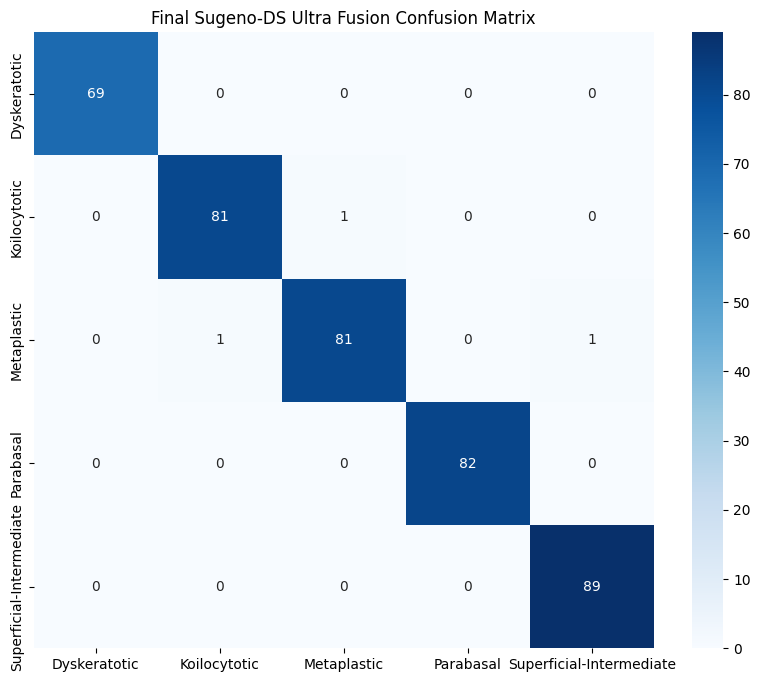

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Final Sugeno-DS Ultra Fusion Confusion Matrix')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', format='jpg')

    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Execute plotting
print("\nGenerating Confusion Matrix...")
plot_confusion_matrix(all_ground_truth, all_fused_preds, full_dataset.class_names)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Fusion Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # ✅ Save as JPG (high resolution)
    plt.savefig("fusion_confusion_matrix.jpg", dpi=300, bbox_inches='tight')

    plt.show()
    plt.close()

# Execute plotting
print("\nGenerating Confusion Matrix...")
plot_confusion_matrix(all_ground_truth, all_fused_preds, full_dataset.class_names)

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_heatmap(self, input_image, class_idx=None):
        self.model.eval()
        output = self.model(input_image)
        
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
        
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Average gradients spatially to get weight per channel
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        # Compute weighted sum of activations
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # ReLU to keep only positive influence, then normalize
        heatmap = F.relu(heatmap)
        heatmap /= (torch.max(heatmap) + 1e-9)
        return heatmap.cpu().detach().numpy()

def display_gradcam(img_tensor, heatmap, title="Grad-CAM"):
    # Convert tensor to numpy image
    img = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    # Basic unnormalization (standard 0-1 range for plotting)
    img = (img - img.min()) / (img.max() - img.min() + 1e-9)
    
    # Resize heatmap to image size
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    
    # Superimpose
    superimposed_img = heatmap_color * 0.4 + (img * 255) * 0.6
    superimposed_img = np.uint8(np.clip(superimposed_img, 0, 255))
    
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')

In [ ]:
def get_fused_gradcam(image_tensor, cnn_model, swin_model, class_metadata):
    # 1. Setup Grad-CAM for both
    # Target ResNet layer 4 and Swin final norm
    cam_cnn = GradCAM(cnn_model, cnn_model.model.layer4[-1])
    cam_swin = GradCAM(swin_model, swin_model.model.norm)

    # 2. Generate individual heatmaps
    # We target the same class (the fused prediction or ground truth)
    out_cnn = F.softmax(cnn_model(image_tensor), dim=1)
    out_trans = F.softmax(swin_model(image_tensor), dim=1)
    
    target_class = torch.argmax(out_cnn + out_trans).item() # Ensemble target
    
    heatmap_cnn = cam_cnn.generate_heatmap(image_tensor, target_class)
    heatmap_swin = cam_swin.generate_heatmap(image_tensor, target_class)

    # 3. Calculate Sugeno Weights for this specific image
    # Using your Min-Entropy (Alpha=Inf) logic
    w_cnn = get_clarity_weight_inf(out_cnn[0])
    w_trans = get_clarity_weight_inf(out_trans[0])
    
    # Calculate mass for the target class
    s_cnn = class_metadata[target_class]['cnn'] * w_cnn
    s_trans = class_metadata[target_class]['trans'] * w_trans
    K_dynamic = torch.pow(torch.abs(out_cnn[0, target_class] - out_trans[0, target_class]), 3)
    
    denom = s_cnn + s_trans + K_dynamic
    m_cnn = (s_cnn / denom).item()
    m_trans = (s_trans / denom).item()

    # 4. Fuzzy Fusion of Heatmaps
    # This represents the 'Fuzzed Layer' attention
    fused_heatmap = (m_cnn * heatmap_cnn) + (m_trans * heatmap_swin)
    
    return fused_heatmap, heatmap_cnn, heatmap_swin

In [ ]:
def find_last_layers(cnn_model, swin_model):
    cnn_target = None
    swin_target = None

    # For CNN: Iterate backwards to find the last 2D Convolution layer
    # Since you have a ParallelAttention module after layer4, we want the last conv in that module
    for name, module in reversed(list(cnn_model.named_modules())):
        if isinstance(module, torch.nn.Conv2d):
            cnn_target = module
            cnn_name = name
            break
            
    # For Swin: Iterate backwards to find the last LayerNorm
    for name, module in reversed(list(swin_model.named_modules())):
        if isinstance(module, torch.nn.LayerNorm):
            swin_target = module
            swin_name = name
            break
            
    return (cnn_target, cnn_name), (swin_target, swin_name)

(cnn_layer, c_name), (swin_layer, s_name) = find_last_layers(cnn_model, swin_model)

print(f"Targeting CNN Layer: {c_name}")
print(f"Targeting Swin Layer: {s_name}")

In [ ]:
def display_full_sugeno_analysis(img_tensor, h_cnn, h_swin, h_fused, class_name):
    # 1. Prepare the original image
    img = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    # Unnormalize to 0-1 range
    img = (img - img.min()) / (img.max() - img.min() + 1e-9)
    
    # 2. Setup plotting grid (1 row, 4 columns)
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    # Panel A: Original Image
    axes[0].imshow(img)
    axes[0].set_title(f"Original: {class_name}", fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    heatmaps = [h_cnn, h_swin, h_fused]
    labels = ["CNN Attention", "Swin Attention", "Fusion"]
    
    for i, (h, label) in enumerate(zip(heatmaps, labels)):
        # Resize and colorize heatmap
        h_resized = cv2.resize(h, (img.shape[1], img.shape[0]))
        h_uint8 = np.uint8(255 * h_resized)
        heatmap_color = cv2.applyColorMap(h_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        # Superimpose
        superimposed = np.uint8(np.clip(heatmap_color * 0.4 + (img * 255) * 0.6, 0, 255))
        
        axes[i+1].imshow(superimposed)
        axes[i+1].set_title(label, fontsize=14, fontweight='bold')
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# Get a batch and pull a specific sample
images, labels = next(iter(test_loader))
idx = 0 # Change this to see different images in the batch
input_tensor = images[idx:idx+1].to(device)
true_label = full_dataset.class_names[labels[idx].item()]

# Generate heatmaps
h_f, h_c, h_s = get_fused_gradcam(input_tensor, cnn_model, swin_model, class_metadata)

# Display everything
display_full_sugeno_analysis(input_tensor, h_c, h_s, h_f, true_label)

In [ ]:
def visualize_all_classes(test_loader, cnn_model, swin_model, class_metadata, class_names):
    # Dictionary to store one sample image per class
    found_classes = {}
    
    print("Searching for samples of all 5 classes...")
    
    # Iterate through loader to find one example of each class
    for images, labels in test_loader:
        for i in range(images.size(0)):
            label_idx = labels[i].item()
            if label_idx not in found_classes:
                found_classes[label_idx] = images[i:i+1]
            
            # Stop once we have all 5 classes
            if len(found_classes) == len(class_names):
                break
        if len(found_classes) == len(class_names):
            break

    # Generate and display Grad-CAM for each class found
    for label_idx in sorted(found_classes.keys()):
        input_tensor = found_classes[label_idx].to(device)
        class_name = class_names[label_idx]
        
        print(f"\nGenerating Analysis for Class: {class_name}")
        
        # Generate heatmaps using your final optimized logic
        h_f, h_c, h_s = get_fused_gradcam_final(
            input_tensor, cnn_model, swin_model, class_metadata
        )
        
        # Display the 4-panel comparison
        display_full_sugeno_analysis(input_tensor, h_c, h_s, h_f, class_name)

# --- EXECUTION ---
visualize_all_classes(
    test_loader, 
    cnn_model, 
    swin_model, 
    class_metadata, 
    full_dataset.class_names
)

In [ ]:
!pip install grad-cam

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
class SugenoFusionWrapper(torch.nn.Module):
    def __init__(self, cnn_model, swin_model, class_metadata):
        super().__init__()
        self.cnn = cnn_model
        self.swin = swin_model
        self.class_metadata = class_metadata

    def forward(self, x):
        out_cnn = torch.softmax(self.cnn(x), dim=1)
        out_trans = torch.softmax(self.swin(x), dim=1)

        fused_outputs = []
        for i in range(x.size(0)):
            fused = compute_sugeno_fusion_99(
                out_cnn[i],
                out_trans[i],
                self.class_metadata
            )
            fused_outputs.append(fused)

        return torch.stack(fused_outputs)

In [ ]:
def swin_reshape_transform(tensor):
    # tensor shape: [B, H, W, C]
    return tensor.permute(0, 3, 1, 2)


cnn_target_layer = cnn_model.base_model.layer4[-1]
swin_target_layer = swin_model.model.layers[-1].blocks[-1].norm1

In [ ]:
def generate_cam(model, target_layer, input_tensor, reshape_transform=None):

    cam = GradCAM(
        model=model,
        target_layers=[target_layer],
        reshape_transform=reshape_transform
    )

    model.eval()

    outputs = model(input_tensor)
    pred_class = outputs.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

    return grayscale_cam[0], pred_class

In [ ]:
def visualize_three_models(input_tensor, cnn_model, swin_model, class_metadata):

    fusion_model = SugenoFusionWrapper(cnn_model, swin_model, class_metadata)

    # CNN CAM
    cam_cnn, class_id = generate_cam(
        cnn_model,
        cnn_target_layer,
        input_tensor
    )

    cam_swin, _ = generate_cam(
        swin_model,
        swin_target_layer,
        input_tensor,
        reshape_transform=None
    )

    # Fusion CAM (use CNN backbone for visualization)
    cam_fusion, _ = generate_cam(
        fusion_model,
        cnn_target_layer,
        input_tensor
    )

    # Prepare original image
    img = input_tensor.squeeze().permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    vis_cnn = show_cam_on_image(img, cam_cnn, use_rgb=True)
    vis_swin = show_cam_on_image(img, cam_swin, use_rgb=True)
    vis_fusion = show_cam_on_image(img, cam_fusion, use_rgb=True)

    plt.figure(figsize=(18,5))

    plt.subplot(1,3,1)
    plt.title("CNN Grad-CAM")
    plt.imshow(vis_cnn)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Swin Grad-CAM")
    plt.imshow(vis_swin)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Sugeno Fusion Grad-CAM")
    plt.imshow(vis_fusion)
    plt.axis("off")

    plt.show()

In [ ]:
images, labels = next(iter(test_loader))
input_tensor = images[0].unsqueeze(0).to(device)

visualize_three_models(input_tensor, cnn_model, swin_model, class_metadata)

In [ ]:
# ======================================================
# ABSOLUTE SAFE CNN + SWIN + SUGENO CAM
# ======================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# ------------------------------------------------------
# TARGET LAYERS
# ------------------------------------------------------

cnn_target = cnn_model.base_model.layer4[-1]

# IMPORTANT: Use entire last layer, NOT block
swin_target = swin_model.model.patch_embed.proj


# ------------------------------------------------------
# SWIN SAFE RESHAPE (NO UNPACKING)
# ------------------------------------------------------

def swin_reshape_transform(tensor):

    # If output is tuple → take first element
    if isinstance(tensor, tuple):
        tensor = tensor[0]

    shape = tensor.shape

    # Case: [B, H, W, C]
    if len(shape) == 4:
        return tensor.permute(0, 3, 1, 2)

    # Case: [B, L, C]
    if len(shape) == 3:
        B = shape[0]
        L = shape[1]
        C = shape[2]
        H = int(np.sqrt(L))
        W = H
        return tensor.reshape(B, H, W, C).permute(0, 3, 1, 2)

    raise RuntimeError(f"Unexpected Swin shape: {shape}")


# ------------------------------------------------------
# GENERATE CAM
# ------------------------------------------------------

def generate_cam(model, target_layer, input_tensor):

    model.eval()

    with GradCAM(
        model=model,
        target_layers=[target_layer]
    ) as cam:

        outputs = model(input_tensor)
        pred_class = outputs.argmax(dim=1).item()
        targets = [ClassifierOutputTarget(pred_class)]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )

    return grayscale_cam[0]


# ------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------

def run_visualization_nnn(input_tensor):

    input_tensor = F.interpolate(
        input_tensor,
        size=(224, 224),
        mode='bilinear',
        align_corners=False
    ).to(device)

    # CNN CAM
    cam_cnn = generate_cam(
        cnn_model,
        cnn_target,
        input_tensor
    )

    # Swin CAM (with safe reshape)
    cam_swin = generate_cam(
        swin_model,
        swin_target,
        input_tensor
    )

    # Sugeno weights
    with torch.no_grad():
        p_cnn = torch.softmax(cnn_model(input_tensor), dim=1)[0]
        p_swin = torch.softmax(swin_model(input_tensor), dim=1)[0]

    w_cnn = get_clarity_weight_inf(p_cnn).item()
    w_swin = get_clarity_weight_inf(p_swin).item()

    total = w_cnn + w_swin + 1e-9
    w_cnn /= total
    w_swin /= total

    cam_fusion = w_cnn * cam_cnn + w_swin * cam_swin

    img = input_tensor.squeeze().permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-9)

    vis_cnn = show_cam_on_image(img, cam_cnn, use_rgb=True)
    vis_swin = show_cam_on_image(img, cam_swin, use_rgb=True)
    vis_fusion = show_cam_on_image(img, cam_fusion, use_rgb=True)

    plt.figure(figsize=(22,5))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("CNN")
    plt.imshow(vis_cnn)
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Swin")
    plt.imshow(vis_swin)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Sugeno Fusion")
    plt.imshow(vis_fusion)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------
# RUN
# ------------------------------------------------------

images, labels = next(iter(test_loader))
input_tensor = images[0].unsqueeze(0)

run_visualization_nnn(input_tensor)

In [ ]:
# ======================================================
# FINAL STABLE CNN + SWIN + SUGENO CAM (NO RESHAPE EVER)
# ======================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# ------------------------------------------------------
# Get real Swin backbone (handle wrapper safely)
# ------------------------------------------------------

def get_backbone(model):
    return model.model if hasattr(model, "model") else model


swin_core = get_backbone(swin_model)


# ------------------------------------------------------
# SAFE TARGET LAYERS
# ------------------------------------------------------

cnn_target = cnn_model.base_model.layer4[-1]

# Hook the LAST BLOCK directly (not norm1)
swin_target = swin_core.layers[-1].blocks[-1]


# ------------------------------------------------------
# CAM FUNCTION (NO reshape_transform)
# ------------------------------------------------------

def generate_cam_clean(model, target_layer, input_tensor):

    with GradCAM(model=model, target_layers=[target_layer]) as cam:

        model.eval()
        outputs = model(input_tensor)
        pred_class = outputs.argmax(dim=1).item()
        targets = [ClassifierOutputTarget(pred_class)]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )

    return grayscale_cam[0]


# ------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------

def run_visualization_clean(input_tensor):

    input_tensor = F.interpolate(
        input_tensor,
        size=(224, 224),
        mode='bilinear',
        align_corners=False
    )

    cam_cnn = generate_cam_clean(
        cnn_model,
        cnn_target,
        input_tensor
    )

    cam_swin = generate_cam_clean(
        swin_model,
        swin_target,
        input_tensor
    )

    # Sugeno weights
    with torch.no_grad():
        p_cnn = torch.softmax(cnn_model(input_tensor), dim=1)[0]
        p_swin = torch.softmax(swin_model(input_tensor), dim=1)[0]

    w_cnn = get_clarity_weight_inf(p_cnn).item()
    w_swin = get_clarity_weight_inf(p_swin).item()

    total = w_cnn + w_swin + 1e-9
    w_cnn /= total
    w_swin /= total

    cam_fusion = w_cnn * cam_cnn + w_swin * cam_swin

    img = input_tensor.squeeze().permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-9)

    vis_cnn = show_cam_on_image(img, cam_cnn, use_rgb=True)
    vis_swin = show_cam_on_image(img, cam_swin, use_rgb=True)
    vis_fusion = show_cam_on_image(img, cam_fusion, use_rgb=True)

    plt.figure(figsize=(22,5))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("CNN")
    plt.imshow(vis_cnn)
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Swin")
    plt.imshow(vis_swin)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Sugeno Fusion")
    plt.imshow(vis_fusion)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------
# RUN
# ------------------------------------------------------

images, labels = next(iter(test_loader))
input_tensor = images[0].unsqueeze(0).to(device)

run_visualization_clean(input_tensor)

In [ ]:
# ----------------------------
# Run On One Sample + Print Info
# ----------------------------

images, labels = next(iter(test_loader))
input_tensor = images[0].unsqueeze(0).to(device)

true_label = labels[0].item()
true_class_name = full_dataset.class_names[true_label]

# Get predictions
with torch.no_grad():
    out_cnn = cnn_model(input_tensor)
    out_swin = swin_model(input_tensor)

pred_cnn = torch.argmax(out_cnn, dim=1).item()
pred_swin = torch.argmax(out_swin, dim=1).item()

pred_cnn_name = full_dataset.class_names[pred_cnn]
pred_swin_name = full_dataset.class_names[pred_swin]

# Print information
print("="*50)
print(f"True Cell Type        : {true_class_name}")
print(f"CNN Prediction        : {pred_cnn_name}")
print(f"Swin Prediction       : {pred_swin_name}")
print("="*50)

# Visualize Grad-CAMs
visualize_three_models(input_tensor)

In [ ]:
def visualize_three_models(input_tensor):

    # ---- CNN CAM ----
    cam_cnn, _ = generate_cam(
        cnn_model,
        cnn_target_layer,
        input_tensor,
        reshape_transform=None
    )

    # ---- Swin CAM ----
    cam_swin, _ = generate_cam(
        swin_model,
        swin_target_layer,
        input_tensor,
        reshape_transform=swin_reshape_transform
    )

    # ---- Sugeno Fusion CAM ----
    with torch.no_grad():
        p_cnn = torch.softmax(cnn_model(input_tensor), dim=1)[0]
        p_swin = torch.softmax(swin_model(input_tensor), dim=1)[0]

    w_cnn = get_clarity_weight_inf(p_cnn).item()
    w_swin = get_clarity_weight_inf(p_swin).item()

    total = w_cnn + w_swin + 1e-9
    w_cnn /= total
    w_swin /= total

    cam_fusion = w_cnn * cam_cnn + w_swin * cam_swin

    # ---- Convert normalized tensor to image ----
    img = input_tensor.squeeze().permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    vis_cnn = show_cam_on_image(img, cam_cnn, use_rgb=True)
    vis_swin = show_cam_on_image(img, cam_swin, use_rgb=True)
    vis_fusion = show_cam_on_image(img, cam_fusion, use_rgb=True)

    # ---- Plot (4 images) ----
    plt.figure(figsize=(22,5))

    plt.subplot(1,4,1)
    plt.title("Original Cell Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("CNN Grad-CAM")
    plt.imshow(vis_cnn)
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Swin Grad-CAM")
    plt.imshow(vis_swin)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Sugeno Fusion Grad-CAM")
    plt.imshow(vis_fusion)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_three_models(input_tensor)

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, class_idx=None):
        self.model.eval()
        output = self.model(input_image)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Weighted combination of channels
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        grad_cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # ReLU and Normalization
        grad_cam = F.relu(grad_cam)
        grad_cam = grad_cam.detach().cpu().numpy()
        grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)
        
        return grad_cam, class_idx

In [41]:
def show_cam_on_image(img, mask):
    # img: original image (RGB, 0-1)
    # mask: generated heatmap (0-1)
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = np.float32(heatmap) / 255
    
    cam = heatmap + np.float32(img)
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

def visualize_gradcam(model, image_tensor, original_image, target_layer):
    # image_tensor: [1, 3, H, W] normalized tensor
    # original_image: [H, W, 3] numpy array (0-1)
    
    cam_extractor = GradCAM(model, target_layer)
    heatmap, class_idx = cam_extractor.generate_heatmap(image_tensor)
    
    # Resize heatmap to match image size
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    result = show_cam_on_image(original_image, heatmap_resized)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original_image)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Grad-CAM (Class {class_idx})")
    plt.imshow(result)
    plt.axis('off')
    plt.show()

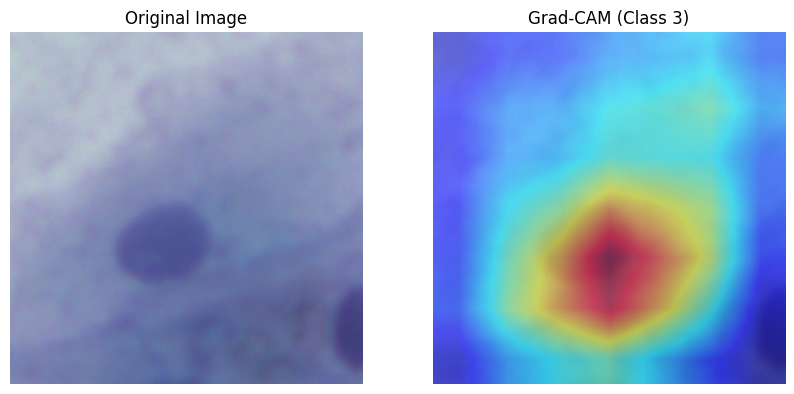

In [43]:
# 1. Load your best model
model = ResNet18ParallelCBAM(num_classes=num_classes).to(device)
model.load_state_dict(torch.load("/kaggle/working/best_ResNet18ParallelCBAM_acc.pth"))
model.to(device)

# 2. Get a sample image from your validation set
images, labels = next(iter(val_loader))
input_tensor = images[0].unsqueeze(0).to(device)

# 3. Convert tensor back to visible numpy image for plotting
# Note: reverse the normalization if you used it in transforms
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
img_for_plot = inv_normalize(images[0]).permute(1, 2, 0).numpy()
img_for_plot = np.clip(img_for_plot, 0, 1)

# 4. Target the last convolutional layer (layer4[-1].conv2)
target = model.base_model.layer4[-1].conv2

# 5. Run Visualization
visualize_gradcam(model, input_tensor, img_for_plot, target)

In [50]:
# Helper to dig through any number of wrappers (Subset, TransformedSubset, etc.)
def find_class_names(obj):
    # Check if the current object has the attribute
    if hasattr(obj, 'class_names'):
        return obj.class_names
    # If it's a wrapper, dig deeper
    if hasattr(obj, 'dataset'):
        return find_class_names(obj.dataset)
    # If it's a list/subset, check the first element's parent if possible
    return None

class_names = find_class_names(val_loader.dataset)

# If still None, we manually define them based on your Dataset class definition
if class_names is None:
    class_names = [
        'Dyskeratotic', 'Koilocytotic', 'Metaplastic', 
        'Parabasal', 'Superficial-Intermediate'
    ]

print(f"Successfully linked classes: {class_names}")

Successfully linked classes: ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial-Intermediate']


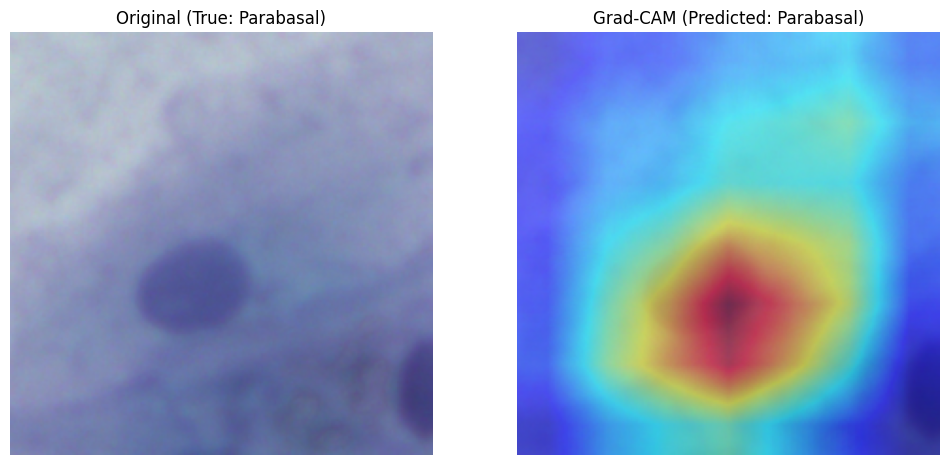

In [51]:
# --- 1. Load your best model ---
model = ResNet18ParallelCBAM(num_classes=len(class_names)).to(device)
model.load_state_dict(torch.load("/kaggle/working/best_ResNet18ParallelCBAM_acc.pth"))
model.eval()
model.to(device)

# --- 2. Get a sample image ---
# We take one batch and pick the first image
images, labels = next(iter(val_loader))
input_tensor = images[0].unsqueeze(0).to(device)
true_label_idx = labels[0].item()

# --- 3. Invert Normalization for Plotting ---
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
img_for_plot = inv_normalize(images[0]).permute(1, 2, 0).numpy()
img_for_plot = np.clip(img_for_plot, 0, 1)

# --- 4. Define the Target Layer ---
# We target the last layer of the ResNet backbone
target_layer = model.base_model.layer4[-1].conv2

# --- 5. Run Visualization ---
# Using the function defined in previous steps
visualize_gradcam_with_labels(
    model=model, 
    image_tensor=input_tensor, 
    original_image=img_for_plot, 
    target_layer=target_layer, 
    classes=class_names
)

In [54]:
class SwinGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, class_idx=None):
        self.model.eval()
        output = self.model(input_image)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Handle different output shapes (B, H, W, C) vs (B, L, C)
        if len(self.activations.shape) == 4:
            # Shape is (B, H, W, C) -> Move C to dimension 1
            activations = self.activations.permute(0, 3, 1, 2)
            gradients = self.gradients.permute(0, 3, 1, 2)
        else:
            # Shape is (B, L, C) -> Reshape to (B, C, H, W)
            b, l, c = self.activations.shape
            h = w = int(np.sqrt(l))
            activations = self.activations.transpose(1, 2).view(b, c, h, w)
            gradients = self.gradients.transpose(1, 2).view(b, c, h, w)

        # Global average pooling of gradients to get weights
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        grad_cam = torch.sum(weights * activations, dim=1).squeeze()
        
        # ReLU and Normalization
        grad_cam = F.relu(grad_cam)
        grad_cam = grad_cam.detach().cpu().numpy()
        grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)
        
        return grad_cam, class_idx

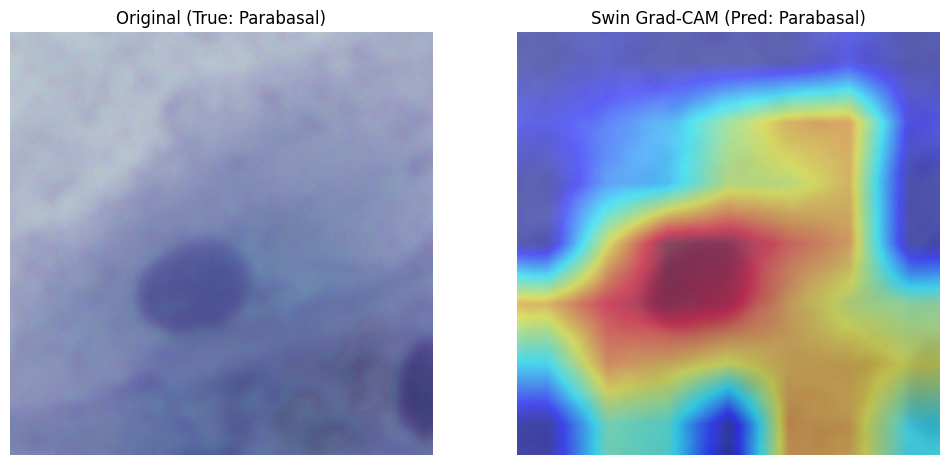

In [55]:
# 1. Load the model (without DataParallel wrapper for easier hook registration)
num_classes = len(class_names) 
model_grad = SwinStandard(num_classes=num_classes).to(device)
state_dict = torch.load(f'best_{model_name}_acc.pth')
model_grad.load_state_dict(state_dict)
model_grad.eval()

# 2. Get data (reuse your previous logic)
images, labels = next(iter(val_loader))
input_tensor = images[0].unsqueeze(0).to(device)

# 3. Choose the target layer
# For timm Swin models, the hierarchy is usually: model.layers[stage_idx].blocks[block_idx]
target_layer = model_grad.model.layers[-1].blocks[-1]

# 4. Generate Heatmap
cam_extractor = SwinGradCAM(model_grad, target_layer)
heatmap, pred_idx = cam_extractor.generate_heatmap(input_tensor)

# 5. Visualization
# Prepare original image
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
img_np = inv_normalize(images[0]).permute(1, 2, 0).cpu().numpy()
img_np = np.clip(img_np, 0, 1)

# Resize heatmap to 224x224
heatmap_resized = cv2.resize(heatmap, (224, 224))
result = show_cam_on_image(img_np, heatmap_resized) # Use previous helper

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f"Original (True: {class_names[labels[0].item()]})")
plt.imshow(img_np)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Swin Grad-CAM (Pred: {class_names[pred_idx]})")
plt.imshow(result)
plt.axis('off')
plt.show()